<a href="https://colab.research.google.com/github/pachterlab/cellmender/blob/main/benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# try:
#     from cellmender import denoise_count_matrix
# except ImportError:
#     print("cellmender not found, installing...")
#     !pip install -U -q cellmender[analysis]

In [11]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import seaborn as sns
import scanpy as sc
from IPython.display import Image, display
# from cellbender.remove_background.downstream import anndata_from_h5
from cellmender import denoise_count_matrix
from cellmender.simulation import simulate_cells
import cellmender.utils as cm_utils
from cellmender.constants import CellBender_Fig2_to_Immune_All_High_celltype_mapping

cellmender_dir = os.path.dirname(os.path.abspath(""))
rver_docker_workspace = "/home/ruser/work/cellmender"

# import importlib
# import cellmender.celltype_ambient
# importlib.reload(cellmender.celltype_ambient)
# from cellmender.celltype_ambient import denoise_count_matrix

# import importlib
# import cellmender.utils as cm_utils
# importlib.reload(cm_utils)
# from cellmender.utils import plot_matrix_scatterplot

# Compare CellBender vs. cellmender

Some datasets of use:
- tiny mouse heart dataset from CellBender (CellBender/examples/remove_background/generate_tiny_10x_dataset.py): https://www.10xgenomics.com/resources/datasets/10-k-heart-cells-from-an-e-18-mouse-v-3-chemistry-3-standard-3-0-0 

- 8k PBMCs from a healthy donor (CellBender Fig2): https://www.10xgenomics.com/datasets/8-k-pbm-cs-from-a-healthy-donor-2-standard-2-1-0
  - see run configuration on page 13 (bottom left) of the [Cellbender manuscript](https://doi.org/10.1038/s41592-023-01943-7)
- heart snRNA-seq (CellBender Fig3): https://singlecell.broadinstitute.org/single_cell/study/SCP1303
  - see run configuration in the file human_dcm_hcm_scportal_03.17.2022_README.txt of [data repository](https://singlecell.broadinstitute.org/single_cell/study/SCP1303/single-nuclei-profiling-of-human-dilated-and-hypertrophic-cardiomyopathy#study-download)

In [ ]:
dataset_name = "heart600k"  # options: pbmc8k, heart600k, tiny_cellbender, simulation1, custom
rerun_tools = True  # if True, requires docker
cellbender_model = "full"  # options: ambient, swapping, full
wompwomp_path = os.path.join(os.path.dirname(cellmender_dir), "wompwomp")  # only needed if dataset_name == "custom"
verbose = 2  # 2 debug, 1 info, 0 warning, -1 error, -2 critical
overwrite = False
# cellbender_env = "/home/jrich/miniconda3/envs/cellbender"
wompwomp_env = "/home/jrich/miniconda3/envs/wompwomp_env"
scar_env = "/home/jrich/miniconda3/envs/scar"
use_cuda = False
threads = 16

# only required if dataset_name == "custom"; if using a dataset option above, then this will override the defaults filled out below
adata_path_raw_custom = None
adata_path_cellmender_custom = None
adata_path_cellbender_custom = None
soupx_out_prefix_custom = None
decontx_out_prefix_custom = None
adata_path_scar_custom = None
sequencing_technology_custom = None
model_pkl_custom = None
matrix_tar_files_dir_custom = None
raw_tar_file_dir_custom = None
filtered_tar_file_dir_custom = None
cellmender_max_iter_custom = None
cellmender_beta_custom = None
cellmender_cell_ambient_fraction_custom = None
cellbender_epochs_custom = None
cellbender_fpr_custom = None
scar_epochs_custom = None
cellbender_total_droplets_custom = None
expected_cells_custom = None
cs_empty_threshold_custom = None
min_genes_custom = None
min_cells_custom = None
umi_top_percentile_to_remove_custom = None
unique_genes_top_percentile_to_remove_custom = None
mt_gene_percentile_to_remove_custom = None
max_mt_percentage_custom = None
n_top_genes_custom = None
n_pcs_custom = None
n_neighbors_custom = None
leiden_resolution_custom = None
marker_genes_custom = None

In [ ]:
data_dir = os.path.join(cellmender_dir, "notebooks", "data", dataset_name)
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellmender_dir, "notebooks", "output", dataset_name)
os.makedirs(out_dir, exist_ok=True)

cellmender_matrix_url = None
cellbender_matrix_url = None
cellbender_matrix_filtered_url = None
cellbender_ckpt_url = None
soupx_matrix_url = None
decontx_matrix_url = None
scar_matrix_url = None

cellmender_log_file = os.path.join(data_dir, "cellmender.log")
cellbender_ckpt = os.path.join(out_dir, "cellbender_ckpt.tar.gz")

if dataset_name == "tiny_cellbender":
    adata_path_raw = f"{data_dir}/tiny_raw_feature_bc_matrix.h5ad"
    adata_path_cellmender = f"{data_dir}/tiny_output_cellmender.h5ad"
    adata_path_cellbender = f"{data_dir}/tiny_output_cellbender.h5"
    soupx_out_prefix = None  # f"{data_dir}/tiny_output_soupx"
    decontx_out_prefix = None  # f"{data_dir}/tiny_output_decontx"
    adata_path_scar = None
    sequencing_technology = "10XV2"
    model_pkl = "Adult_Mouse_Gut.pkl"  # path to celltypist model pkl file - this is a mouse heart dataset, but this is really just for debugging anyways
    
    if not os.path.exists(adata_path_raw):
        raise FileNotFoundError(f"Original matrix file not found: {adata_path_raw}. Create with CellBender's `python generate_tiny_10x_dataset.py` (see https://github.com/broadinstitute/CellBender):")
    
    matrix_tar_files_dir = None
    raw_tar_file_dir = None
    filtered_tar_file_dir = None

    cellmender_matrix_url = None
    cellbender_matrix_url = None
    cellbender_matrix_filtered_url = None
    cellbender_ckpt_url = None
    soupx_matrix_url = None
    decontx_matrix_url = None

    cellmender_max_iter = 10
    cellmender_beta = 0.03
    cellmender_cell_ambient_fraction = 0.01
    cellbender_epochs = 2
    cellbender_fpr = 0.01
    cellbender_zdim = 64
    cellbender_total_droplets = 2000
    scar_epochs = 2
    expected_cells = 500
    cs_empty_threshold = 1000
    min_genes = 5
    min_cells = 3
    umi_top_percentile_to_remove = None
    unique_genes_top_percentile_to_remove = None
    mt_gene_percentile_to_remove = None
    max_mt_percentage = 50
    n_top_genes = 2000
    n_pcs = 45
    n_neighbors = 15
    leiden_resolution = 1.0
    marker_genes = {
        'Resting CD4+ T cells': ["Hbb-bs", "mt-Co3", "mt-Atp6"],
        'Paneth.progenitor': ["Eef1a1"],
        'Plasma cell': ["H3f3b"],
        'Naive B cells': ["Rpl13", "Rplp0"]
    }
elif dataset_name == "pbmc8k":
    adata_path_raw = f"{data_dir}/pbmc8k_raw_gene_bc_matrices_h5.h5"
    adata_path_cellmender = f"{data_dir}/pbmc8k_output_cellmender.h5ad"
    adata_path_cellbender = f"{data_dir}/pbmc8k_output_cellbender.h5"
    soupx_out_prefix = f"{data_dir}/pbmc8k_output_soupx"
    decontx_out_prefix = f"{data_dir}/pbmc8k_output_decontx"
    adata_path_scar = f"{data_dir}/pbmc8k_output_scar.h5ad"
    sequencing_technology = "10XV2"
    model_pkl = "Immune_All_High.pkl"  # path to celltypist model pkl file

    if not os.path.exists(adata_path_raw):
        !wget -O {adata_path_raw} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_raw_gene_bc_matrices_h5.h5
    
    matrix_tar_files_dir = os.path.join(data_dir, "matrix_tar_files")
    os.makedirs(matrix_tar_files_dir, exist_ok=True)
    raw_tar_file_dir = os.path.join(matrix_tar_files_dir, "raw_gene_bc_matrices", "GRCh38")
    filtered_tar_file_dir = os.path.join(matrix_tar_files_dir, "filtered_gene_bc_matrices", "GRCh38")
    if not os.path.exists(raw_tar_file_dir) and rerun_tools:
        raw_tar_path = os.path.join(matrix_tar_files_dir, "pbmc8k_raw_gene_bc_matrices.tar.gz")
        !wget -O {raw_tar_path} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_raw_gene_bc_matrices.tar.gz
        !tar -xvzf {raw_tar_path} -C {matrix_tar_files_dir}
    if not os.path.exists(filtered_tar_file_dir) and rerun_tools:
        filtered_tar_path = os.path.join(matrix_tar_files_dir, "pbmc8k_filtered_gene_bc_matrices.tar.gz")
        !wget -O {filtered_tar_path} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_filtered_gene_bc_matrices.tar.gz
        !tar -xvzf {filtered_tar_path} -C {matrix_tar_files_dir}

    cellmender_matrix_url = "https://caltech.box.com/shared/static/dltpt6ixhvzg0rb6h1058aamrcmi7oy7.h5ad"
    cellbender_matrix_url = "https://caltech.box.com/shared/static/trxd26eqmr33cg3ot0l3jins9s193ob6.h5"
    cellbender_matrix_filtered_url = "https://caltech.box.com/shared/static/bnilabzuvdvtm1knpsfgy89php938qft.h5"
    cellbender_ckpt_url = "https://caltech.box.com/shared/static/hj41un9dz0pk5j10t8dyfj2mbllzrp6s.gz"
    soupx_matrix_url = "https://caltech.box.com/shared/static/7lhpw8bgwf3b3gyl7wgqe15h3yhxamld.gz"
    decontx_matrix_url = "https://caltech.box.com/shared/static/zzfs06lp634g2rhuuph200rvga08atzh.gz"
    scar_matrix_url = ""
    
    cellmender_max_iter = 40
    cellmender_beta = 0.03
    cellmender_cell_ambient_fraction = 0.01
    cellbender_epochs = 150
    cellbender_fpr = 0.01
    cellbender_zdim = 64
    cellbender_total_droplets = 12_000
    scar_epochs = 200
    expected_cells = 9000
    cs_empty_threshold = 10
    min_genes = 0
    min_cells = 0
    umi_top_percentile_to_remove = 5
    unique_genes_top_percentile_to_remove = 5
    mt_gene_percentile_to_remove = 10
    max_mt_percentage = None
    n_top_genes = 2000
    n_pcs = 25
    n_neighbors = 20
    leiden_resolution = 1.0
    marker_genes = {
        "Monocytes/neutrophils": ["S100A8", "S100A9", "S100A12", "FCGR3A"],
        "Monocytes/pDCs": ["LYZ", "CST3", "FCN1", "LILRA4"],
        "T": ["IL32", "TRAC", "CCR7", "FOXP3", "CD8A", "CD8B", "NKG7", "GNLY", "TRGC1", "SLC4A10"],
        "B": ["IGHD", "CD79A", "FCER2", "TNFRSF13B"],
        "NK": ["KLRF1", "SPON2"],
        "Progenitor": ["PPBP"],
        "Baso./neutro./progenitor": ["SDPR", "CLU"],
        "(Broad expression)": ["PTPRC"]
    }
elif dataset_name == "heart600k":
    adata_path_cellmender = f"{data_dir}/human_dcm_hcm_scportal_03.17.2022_cellmender.h5ad"
    adata_path_cellbender = f"{data_dir}/human_dcm_hcm_scportal_03.17.2022_cellbender.h5ad"
    soupx_out_prefix = f"{data_dir}/human_dcm_hcm_output_soupx"
    decontx_out_prefix = f"{data_dir}/human_dcm_hcm_output_decontx"
    adata_path_scar = f"{data_dir}/human_dcm_hcm_output_scar.h5ad"
    sequencing_technology = "10XV3"
    model_pkl = "Healthy_Adult_Heart.pkl"  # path to celltypist model pkl file
    
    matrix_tar_files_dir = os.path.join(data_dir, "matrix_tar_files")
    os.makedirs(matrix_tar_files_dir, exist_ok=True)
    raw_tar_file_dir = os.path.join(matrix_tar_files_dir, "raw_gene_bc_matrices", "SCP1303", "expression", "614a0209771a5b0d7f033712")
    if not os.path.exists(raw_tar_file_dir):
        if rerun_tools:
            raise FileNotFoundError(f"Original matrix file not found: {raw_tar_file_dir}. Download raw matrix, barcodes, and genes files from https://singlecell.broadinstitute.org/single_cell/data/public/SCP1303/single-nuclei-profiling-of-human-dilated-and-hypertrophic-cardiomyopathy?filename=DCM_HCM_Expression_Matrix_raw_counts_V1.mtx and extract to {raw_tar_file_dir}")
        else:
            !wget -P {matrix_tar_files_dir} xxxxxxxxxxx
            !tar -xvzf raw_gene_bc_matrices.tar.gz -C {data_dir}

    cellmender_matrix_url = "xxxx"
    cellbender_matrix_url = "xxxx"
    cellbender_matrix_filtered_url = "xxxx"
    cellbender_ckpt_url = "xxxx"
    soupx_matrix_url = "xxxx"
    decontx_matrix_url = "xxxx"
    scar_matrix_url = "xxxx"
    
    cellmender_max_iter = 40
    cellmender_beta = 0.03
    cellmender_cell_ambient_fraction = 0.01
    cellbender_epochs = 150
    cellbender_fpr = 0.01
    cellbender_zdim = 100
    cellbender_total_droplets = 25_000
    scar_epochs = 200
    expected_cells = 5000
    cs_empty_threshold = 10
    min_genes = 0
    min_cells = 0
    umi_top_percentile_to_remove = 0
    unique_genes_top_percentile_to_remove = 0
    mt_gene_percentile_to_remove = 0
    max_mt_percentage = None
    n_top_genes = 2000
    n_pcs = 25
    n_neighbors = 20
    leiden_resolution = 0.6
    marker_genes = ["TTN", "RYR2", "FHL2", "CTNNA3", "SLC8A1", "SORBS2", "FGF12", "MYBPC3", "MYOM1", "ABLIM1", "SORBS1", "DMD", "CACNA1C", "PDE3A", "PRKG1", "LAMA2", "DCN", "GSN"]

    filtered_tar_file_dir = os.path.join(matrix_tar_files_dir, "filtered_gene_bc_matrices")
    adata_path_raw = f"{raw_tar_file_dir}/DCM_HCM_Expression_Matrix_"

    #$$$$
    # if not os.path.exists(filtered_tar_file_dir) and rerun_tools:
    #     umi_cutoff = 500  # determined below
    #     adata_raw = sc.read_10x_mtx(adata_path_raw)
    #     adata_raw.obs['n_counts'] = np.array(adata_raw.X.sum(axis=1)).flatten()
    #     adata_filtered = adata_raw[adata_raw.obs['n_counts'] >= umi_cutoff].copy()
    #     cm_utils.write_10x_mtx(adata_filtered, filtered_tar_file_dir, gene_symbol_col='gene_symbols', gene_id_col='gene_ids')

# elif dataset_name == "simulation1":
#     if not os.path.exists(adata_path_raw):
#         adata = cm_utils.simulate_cells(adata_path_raw, ...)
    
#     paths = cm_utils.write_10x_like(adata, matrix_tar_files_dir)

#     # # soupx inputs
#     # matrix_tar_files_dir = matrix_tar_files_dir
#     adata_soupx_obs_csv = paths["celltypes"]
#     # soupx_out_prefix

#     # # decontx inputs
#     raw_tar_file_dir = paths["raw"]
#     filtered_tar_file_dir = paths["filtered"]
#     sequencing_technology = paths["technology"]
#     # decontx_out_prefix
#     #!!! continue filling out

# set any custom variables provided by the user
for var in ["adata_path_raw", "adata_path_cellmender", "adata_path_cellbender", "soupx_out_prefix", "decontx_out_prefix", "sequencing_technology", "model_pkl", "matrix_tar_files_dir", "raw_tar_file_dir", "filtered_tar_file_dir", "cellmender_max_iter", "cellmender_beta", "cellmender_cell_ambient_fraction", "cellbender_epochs", "cellbender_fpr", "cellbender_zdim", "cellbender_total_droplets", "scar_epochs", "expected_cells", "cs_empty_threshold", "min_genes", "min_cells", "umi_top_percentile_to_remove", "unique_genes_top_percentile_to_remove", "mt_gene_percentile_to_remove", "max_mt_percentage", "n_top_genes", "n_pcs", "n_neighbors", "leiden_resolution", "marker_genes"]:
    custom = globals().get(f"{var}_custom")
    if custom is not None:
        globals()[var] = custom

adata_path_cellbender_filtered = adata_path_cellbender.replace(".h5", "_filtered.h5")

--2025-11-18 02:11:28--  https://singlecell.broadinstitute.org/single_cell/data/public/SCP1303/single-nuclei-profiling-of-human-dilated-and-hypertrophic-cardiomyopathy?filename=DCM_HCM_Expression_Matrix_raw_counts_V1.mtx
Resolving singlecell.broadinstitute.org (singlecell.broadinstitute.org)... 34.120.207.56
Connecting to singlecell.broadinstitute.org (singlecell.broadinstitute.org)|34.120.207.56|:443... connected.
ERROR: The certificate of ‘singlecell.broadinstitute.org’ is not trusted.
ERROR: The certificate of ‘singlecell.broadinstitute.org’ hasn't got a known issuer.
--2025-11-18 02:11:28--  https://singlecell.broadinstitute.org/single_cell/data/public/SCP1303/single-nuclei-profiling-of-human-dilated-and-hypertrophic-cardiomyopathy?filename=DCM_HCM_Expression_Matrix_genes_V1.tsv
Resolving singlecell.broadinstitute.org (singlecell.broadinstitute.org)... 34.120.207.56
Connecting to singlecell.broadinstitute.org (singlecell.broadinstitute.org)|34.120.207.56|:443... connected.
ERROR: T

In [17]:
!echo wget -P {raw_tar_file_dir} https://singlecell.broadinstitute.org/single_cell/data/public/SCP1303/single-nuclei-profiling-of-human-dilated-and-hypertrophic-cardiomyopathy?filename=DCM_HCM_Expression_Matrix_raw_counts_V1.mtx

wget -P /home/jrich/Desktop/cellmender/notebooks/data/heart600k/matrix_tar_files/raw_gene_bc_matrices https://singlecell.broadinstitute.org/single_cell/data/public/SCP1303/single-nuclei-profiling-of-human-dilated-and-hypertrophic-cardiomyopathy?filename=DCM_HCM_Expression_Matrix_raw_counts_V1.mtx


## Raw

In [ ]:
if adata_path_raw.endswith(".h5ad"):
    adata_raw = ad.read_h5ad(adata_path_raw)
elif adata_path_raw.endswith(".h5"):
    adata_raw = sc.read_10x_h5(adata_path_raw)
else:  # assume 10x
    try:
        adata_raw = sc.read_10x_mtx(adata_path_raw)
    except Exception as e:
        raise ValueError(f"Original matrix file must be either .h5ad, .h5, or 10x format. Found: {adata_path_raw}")
adata_raw.var_names_make_unique()

ValueError: Original matrix file must be either .h5ad or .h5 format. Found: /home/jrich/Desktop/cellmender/notebooks/data/heart600k/matrix_tar_files/raw_gene_bc_matrices/DCM_HCM_Expression_Matrix_

## Knee plot - use this output to estimate cs_empty_threshold

UMI cutoff for expected cells (9000): 298.00


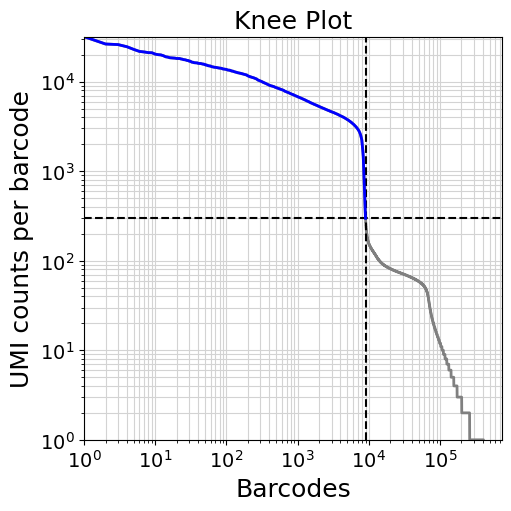

In [ ]:
umi_cutoff = cm_utils.knee_plot(adata_raw, expected_cells=expected_cells, out_path=os.path.join(out_dir, "knee_plot.png"))

In [ ]:
# umi_cutoff = 0  #!!! optionally update from knee plot

## cellmender

In [ ]:
%%time
if not os.path.exists(adata_path_cellmender) or overwrite:
    if rerun_tools:
        adata = adata_raw.copy()
        adata = cm_utils.determine_cell_types(adata, model_pkl=model_pkl, filter_empty=True, expected_cells=expected_cells, verbose=verbose)
        _ = denoise_count_matrix(adata, adata_out=adata_path_cellmender, max_iter=cellmender_max_iter, beta=cellmender_beta, eps=1e-9, empty_droplet_method="threshold", expected_cells=expected_cells, cell_ambient_fraction=cellmender_cell_ambient_fraction, verbose=verbose, log_file=cellmender_log_file)
    else:
        !wget -O {adata_path_cellmender} {cellmender_matrix_url}

CPU times: user 202 μs, sys: 0 ns, total: 202 μs
Wall time: 173 μs


In [ ]:
adata_cellmender = ad.read_h5ad(adata_path_cellmender)
adata_cellmender = adata_cellmender[~adata_cellmender.obs["is_empty"]].copy()
adata_cellmender.var_names_make_unique()
print(f"Counts are less than or equal check for CellMender: {cm_utils.check_counts_less_equal(adata_raw, adata_cellmender)}")

KeyboardInterrupt: 

## CellBender (v0.3.0)

In [ ]:
%%time
if not os.path.exists(adata_path_cellbender) or overwrite:
     if rerun_tools:
          runtime = "--cuda" if use_cuda else f"--cpu-threads {threads}"
          gpus = "--gpus all" if use_cuda else ""
          input_path = adata_path_raw.replace(f"{cellmender_dir}/notebooks/data", "/data")
          output_dir = os.path.dirname(adata_path_cellbender).replace(f"{cellmender_dir}/notebooks/data", "/data")
          output_path = adata_path_cellbender.replace(f"{cellmender_dir}/notebooks/data", "/data")
          ckpt_out_path = os.path.join(data_dir, "cellbender_ckpt.tar.gz").replace(f"{cellmender_dir}/notebooks/data", "/data")
          !docker run --rm {gpus} -v {cellmender_dir}/notebooks/data:/data us.gcr.io/broad-dsde-methods/cellbender:0.3.0 \
               bash -c \"mkdir -p {output_dir} \&\& cellbender remove-background \
               --input {input_path} \
               --output {output_path} \
               --expected-cells {expected_cells} \
               --total-droplets-included {cellbender_total_droplets} \
               --epochs {cellbender_epochs} \
               --fpr {cellbender_fpr} \
               --z-dim {cellbender_zdim} \
               --model {cellbender_model} \
               {runtime} \&\& \
               mv ckpt.tar.gz {ckpt_out_path}\"
     else:
          !wget -O {adata_path_cellbender} {cellbender_matrix_url}
          !wget -O {adata_path_cellbender_filtered} {cellbender_matrix_filtered_url}
          !wget -O {cellbender_ckpt} {cellbender_ckpt_url}

CPU times: user 0 ns, sys: 60 μs, total: 60 μs
Wall time: 87.5 μs


In [ ]:
# adata_cellbender_with_empty_droplets = anndata_from_h5(adata_path_cellbender)
# adata_cellbender = adata_cellbender_with_empty_droplets[adata_cellbender_with_empty_droplets.obs['cell_probability'] > 0.5]
adata_cellbender = sc.read_10x_h5(adata_path_cellbender_filtered, gex_only=False)
adata_cellbender.var_names_make_unique()
print(f"Counts are less than or equal check for CellBender: {cm_utils.check_counts_less_equal(adata_raw, adata_cellbender)}")

/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Counts are less than or equal check for CellBender: True


## SoupX (v1.6.2)

In [ ]:
%%time
if soupx_out_prefix and (not os.path.exists(f"{soupx_out_prefix}.mtx") or overwrite):
    if rerun_tools:
        adata_soupx_obs_csv = f"{data_dir}/pbmc8k_soupx_obs.csv"
        if not os.path.exists(adata_soupx_obs_csv) or overwrite:
            adata_soupx_tmp = cm_utils.load_adata(filtered_tar_file_dir)
            adata_soupx_tmp = cm_utils.run_scanpy_preprocessing_and_clustering(adata_soupx_tmp, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
            adata_soupx_tmp.obs.to_csv(adata_soupx_obs_csv)

        !docker run --rm \
            -w /home/ruser/work \
            -v {cellmender_dir}:{rver_docker_workspace} \
            josephrich98/cellmender_tutorials:soupx.0.1.0 \
            Rscript {rver_docker_workspace}/scripts/run_soupx.R \
                {matrix_tar_files_dir.replace(cellmender_dir, rver_docker_workspace)} \
                {adata_soupx_obs_csv.replace(cellmender_dir, rver_docker_workspace)} \
                {soupx_out_prefix.replace(cellmender_dir, rver_docker_workspace)}
    else:
        !wget -O {soupx_out_prefix}.tar.gz {soupx_matrix_url}
        !tar -xvzf {soupx_out_prefix}.tar.gz -C {os.path.dirname(soupx_out_prefix)}

CPU times: user 57 μs, sys: 4 μs, total: 61 μs
Wall time: 71 μs


In [ ]:
adata_soupx = sc.read_10x_mtx(soupx_out_prefix)
adata_soupx.var_names_make_unique()
print(f"Counts are less than or equal check for SoupX: {cm_utils.check_counts_less_equal(adata_raw, adata_soupx)}")

Counts are less than or equal check for SoupX: True


## DecontX (v1.8.0)

In [ ]:
%%time
if decontx_out_prefix and (not os.path.exists(f"{decontx_out_prefix}.mtx") or overwrite):
    if rerun_tools:
        !docker run --rm \
            -w /home/ruser/work \
            -v {cellmender_dir}:{rver_docker_workspace} \
            josephrich98/cellmender_tutorials:decontx.0.1.0 \
            Rscript {rver_docker_workspace}/scripts/run_decontx.R \
                {raw_tar_file_dir.replace(cellmender_dir, rver_docker_workspace)} \
                {filtered_tar_file_dir.replace(cellmender_dir, rver_docker_workspace)} \
                {sequencing_technology} \
                {decontx_out_prefix.replace(cellmender_dir, rver_docker_workspace)}
    else:
        !wget -O {decontx_out_prefix}.tar.gz {decontx_matrix_url}
        !tar -xvzf {decontx_out_prefix}.tar.gz -C {os.path.dirname(decontx_out_prefix)}

CPU times: user 0 ns, sys: 79 μs, total: 79 μs
Wall time: 101 μs


In [ ]:
adata_decontx = sc.read_10x_mtx(decontx_out_prefix)
adata_decontx.obs_names = [name.replace("GRCh38_", "", 1) for name in adata_decontx.obs_names]
adata_decontx.var_names_make_unique()
print(f"Counts are less than or equal check for DecontX: {cm_utils.check_counts_less_equal(adata_raw, adata_decontx)}")

Counts are less than or equal check for DecontX: True


## scAR (v0.7.0)

In [ ]:
%%time
if adata_path_scar and (not os.path.exists(adata_path_scar) or overwrite):
     if rerun_tools:
          runtime = "--cuda" if use_cuda else ""
          conda_run_flag = "-p" if "/" in scar_env else "-n"
          !conda run {conda_run_flag} {scar_env} \
            python {cellmender_dir}/scripts/run_scar.py \
            -r {raw_tar_file_dir} \
            -f {filtered_tar_file_dir} \
            -o {adata_path_scar} \
            {runtime} \
            --epochs {scar_epochs}
     else:
          !wget -O {adata_path_scar} {scar_matrix_url}

CPU times: user 56 μs, sys: 0 ns, total: 56 μs
Wall time: 66.3 μs


In [ ]:
adata_scar = None
if adata_path_scar:
    adata_scar = ad.read_h5ad(adata_path_scar)
    adata_scar.var_names_make_unique()
    print(f"Counts are less than or equal check for scAR: {cm_utils.check_counts_less_equal(adata_raw, adata_scar)}")

Counts are less than or equal check for CellMender: False


# Analysis

In [ ]:
print(f"Raw:\n{adata_raw}\n\n")
print(f"cellmender:\n{adata_cellmender}\n\n")
print(f"CellBender:\n{adata_cellbender}\n\n")
print(f"SoupX:\n{adata_soupx}\n\n")
print(f"DecontX:\n{adata_decontx}\n\n")
print(f"scAR:\n{adata_scar}\n\n")

Raw:
AnnData object with n_obs × n_vars = 737280 × 33694
    var: 'gene_ids'


cellmender:
AnnData object with n_obs × n_vars = 9000 × 33694
    obs: 'is_empty', 'celltype', 'cell_ambient_fraction', 'alpha_hat', 'z_hat'
    var: 'gene_ids', 'ambient_fraction', 'ambient_hat'
    uns: 'beta_hat', 'celltype_names', 'celltype_profile', 'celltype_profile_genes', 'loglike', 'p_hat'
    layers: 'denoised'


CellBender:
AnnData object with n_obs × n_vars = 8752 × 33694
    var: 'gene_ids', 'feature_types', 'genome'


SoupX:
AnnData object with n_obs × n_vars = 8381 × 33694


DecontX:
AnnData object with n_obs × n_vars = 8381 × 33694


scAR:
AnnData object with n_obs × n_vars = 8381 × 33694
    var: 'gene_ids', 'feature_types'
    uns: 'ambient_profile_Gene Expression', 'ambient_profile_all'
    layers: 'raw'




## UpSet plot of retained cells

/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sty

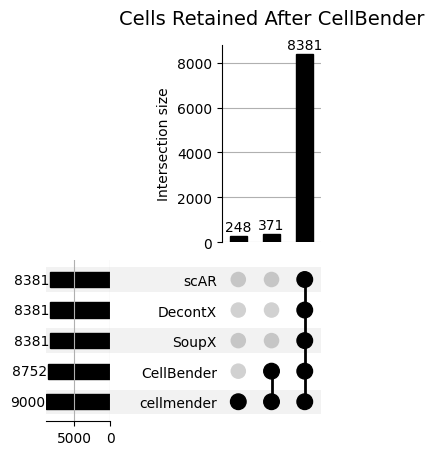

In [ ]:
upset_data_dict = {
    # "Raw": set(adata_raw.obs_names),
    "cellmender": set(adata_cellmender.obs_names),
    "CellBender": set(adata_cellbender.obs_names),
    "SoupX": set(adata_soupx.obs_names) if adata_soupx is not None else None,
    "DecontX": set(adata_decontx.obs_names) if adata_decontx is not None else None,
    "scAR": set(adata_scar.obs_names) if adata_scar is not None else None
}

_ = cm_utils.make_upset_plot(upset_data_dict, title="Cells Retained After CellBender", out_path=os.path.join(out_dir, "cells_retained_upset.png"))

## Scatterplot of cell x gene expression differences

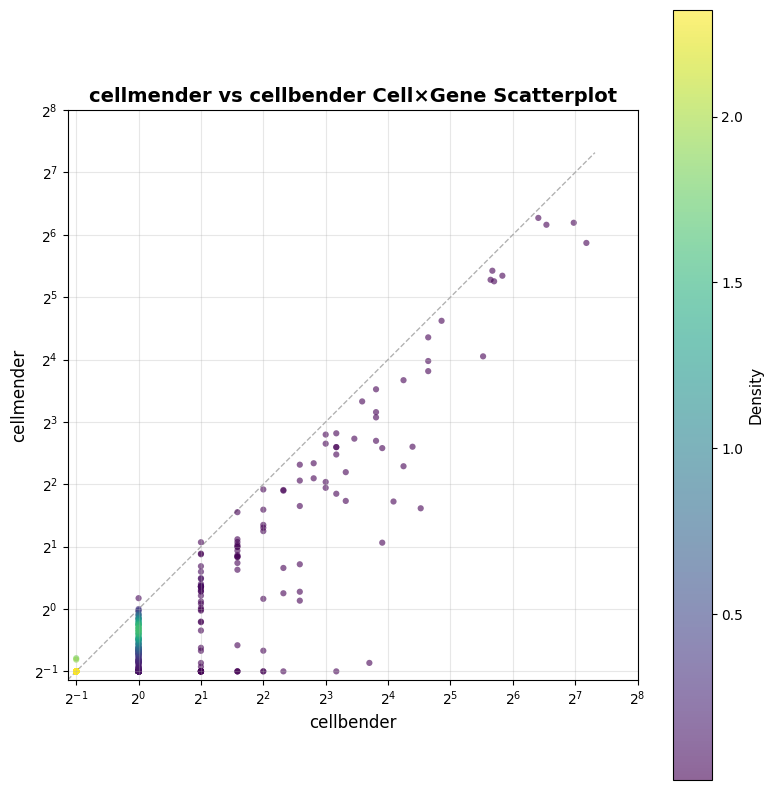

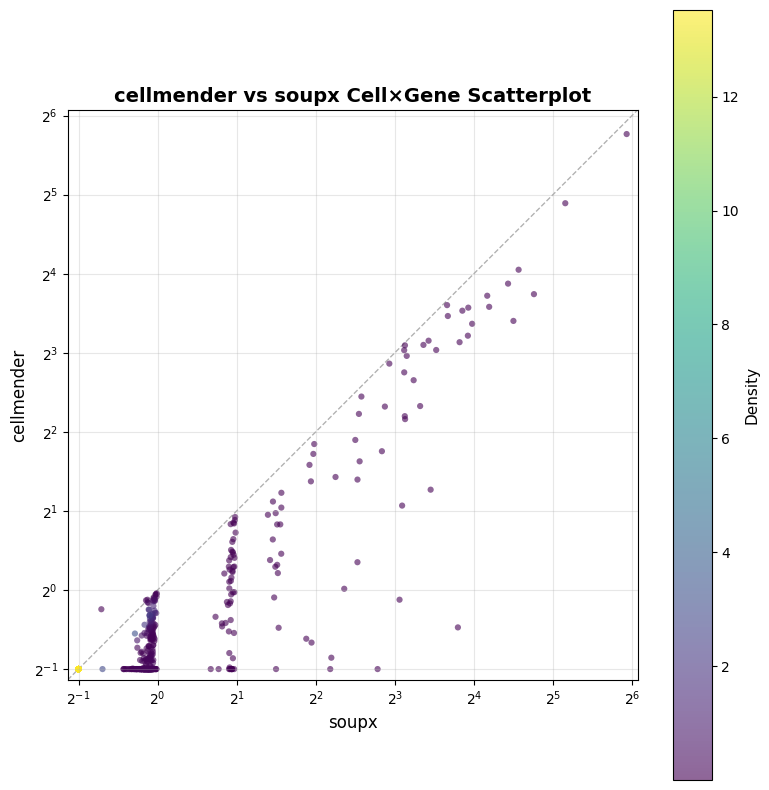

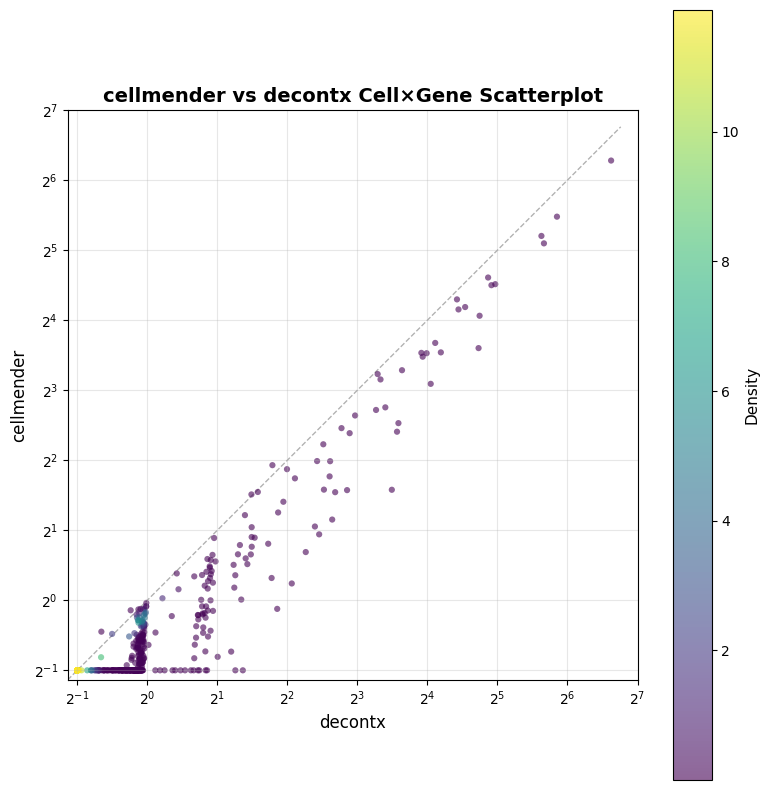

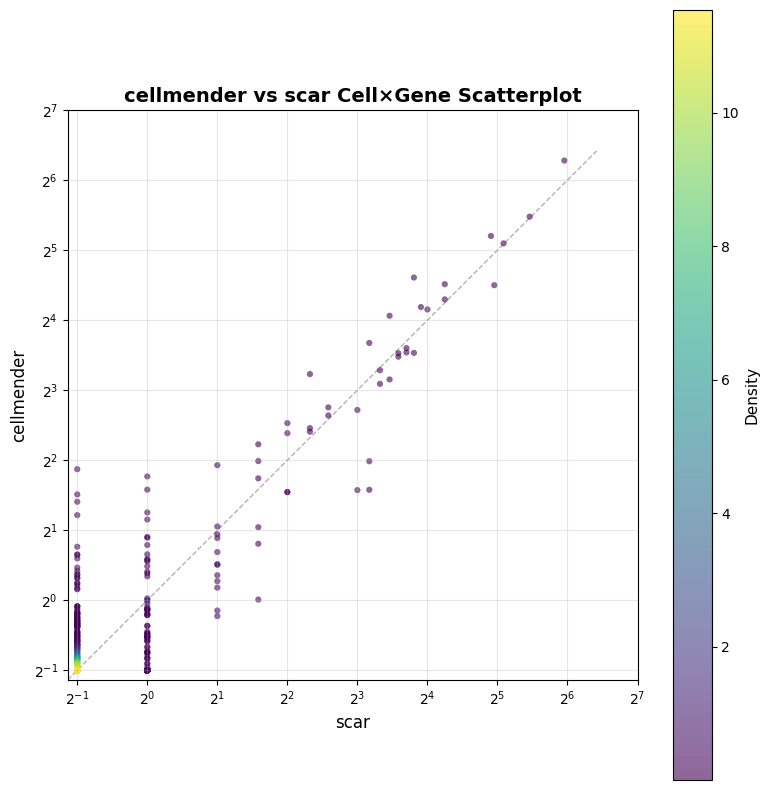

In [ ]:
max_points = 10_000
cm_utils.plot_matrix_scatterplot(adata_cellbender, adata_cellmender, scale="log", x_axis="cellbender", y_axis="cellmender", max_points=max_points, out_path=os.path.join(out_dir, f"cellmender_vs_cellbender_expression_scatterplot_{max_points}points.png"), show=True)
if adata_soupx:
    cm_utils.plot_matrix_scatterplot(adata_soupx, adata_cellmender, scale="log", x_axis="soupx", y_axis="cellmender", max_points=max_points, out_path=os.path.join(out_dir, f"cellmender_vs_soupx_expression_scatterplot_{max_points}points.png"), show=True)
if adata_decontx:
    cm_utils.plot_matrix_scatterplot(adata_decontx, adata_cellmender, scale="log", x_axis="decontx", y_axis="cellmender", max_points=max_points, out_path=os.path.join(out_dir, f"cellmender_vs_decontx_expression_scatterplot_{max_points}points.png"), show=True)
if adata_scar:
    cm_utils.plot_matrix_scatterplot(adata_scar, adata_cellmender, scale="log", x_axis="scar", y_axis="cellmender", max_points=max_points, out_path=os.path.join(out_dir, f"cellmender_vs_scar_expression_scatterplot_{max_points}points.png"), show=True)

## Histogram of per-cell Pearson correlations

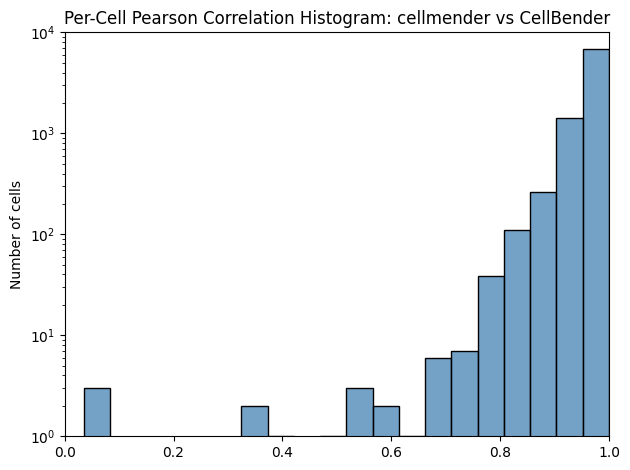

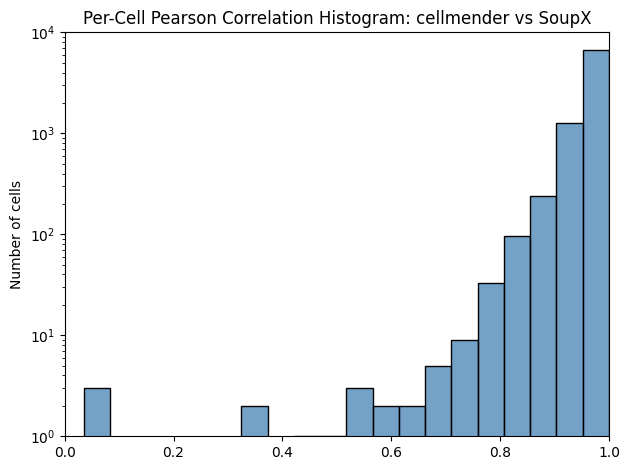

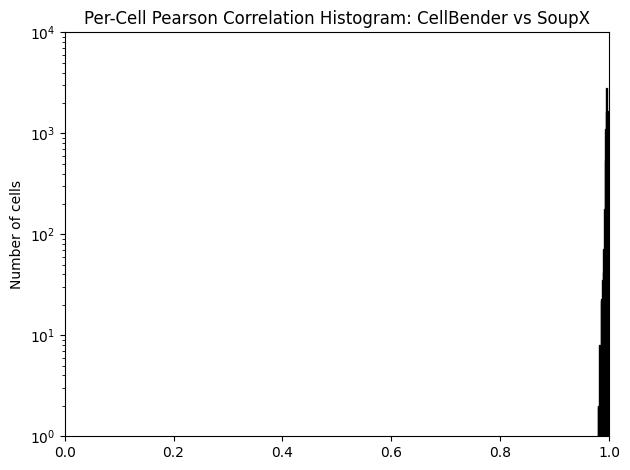

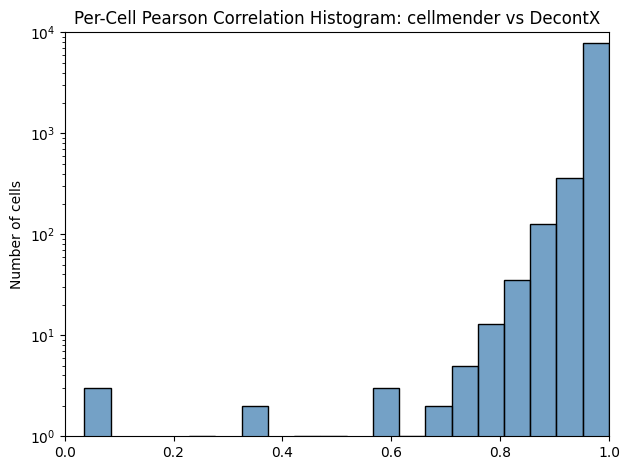

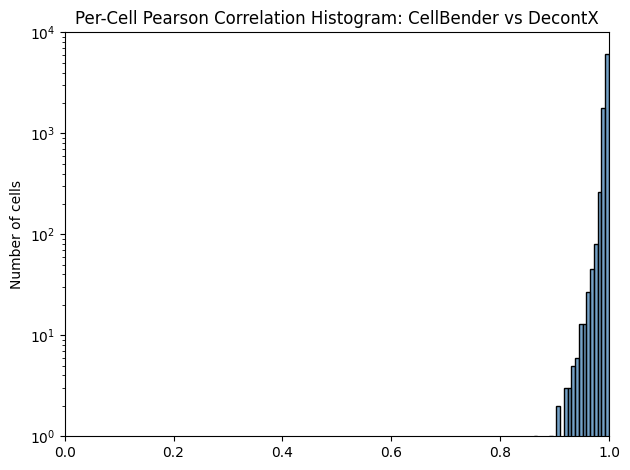

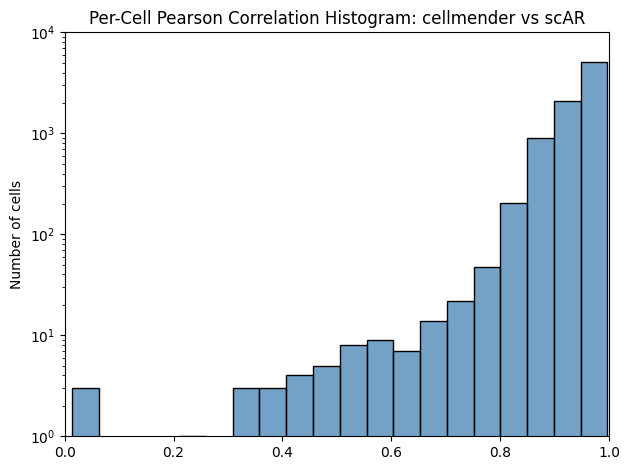

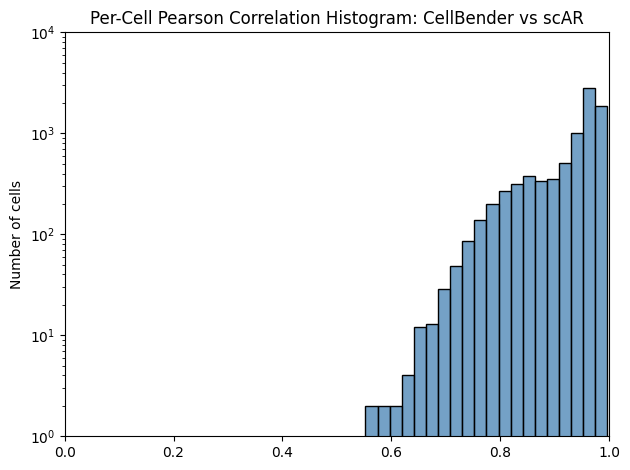

In [ ]:
cm_utils.plot_per_cell_correlation(adata_cellmender, adata_cellbender, title="Per-Cell Pearson Correlation Histogram: cellmender vs CellBender", out_path=os.path.join(out_dir, "cellmender_vs_cellbender_per_cell_correlation.png"))
if adata_soupx:
    cm_utils.plot_per_cell_correlation(adata_cellmender, adata_soupx, title="Per-Cell Pearson Correlation Histogram: cellmender vs SoupX", out_path=os.path.join(out_dir, "cellmender_vs_soupx_per_cell_correlation.png"))
    cm_utils.plot_per_cell_correlation(adata_cellbender, adata_soupx, title="Per-Cell Pearson Correlation Histogram: CellBender vs SoupX", out_path=os.path.join(out_dir, "cellbender_vs_soupx_per_cell_correlation.png"))
if adata_decontx:
    cm_utils.plot_per_cell_correlation(adata_cellmender, adata_decontx, title="Per-Cell Pearson Correlation Histogram: cellmender vs DecontX", out_path=os.path.join(out_dir, "cellmender_vs_decontx_per_cell_correlation.png"))
    cm_utils.plot_per_cell_correlation(adata_cellbender, adata_decontx, title="Per-Cell Pearson Correlation Histogram: CellBender vs DecontX", out_path=os.path.join(out_dir, "cellbender_vs_decontx_per_cell_correlation.png"))
if adata_scar:
    cm_utils.plot_per_cell_correlation(adata_cellmender, adata_scar, title="Per-Cell Pearson Correlation Histogram: cellmender vs scAR", out_path=os.path.join(out_dir, "cellmender_vs_scar_per_cell_correlation.png"))
    cm_utils.plot_per_cell_correlation(adata_cellbender, adata_scar, title="Per-Cell Pearson Correlation Histogram: CellBender vs scAR", out_path=os.path.join(out_dir, "cellbender_vs_scar_per_cell_correlation.png"))

## Deviation from raw

Total differences for cellmender: 18,757,983.485962015


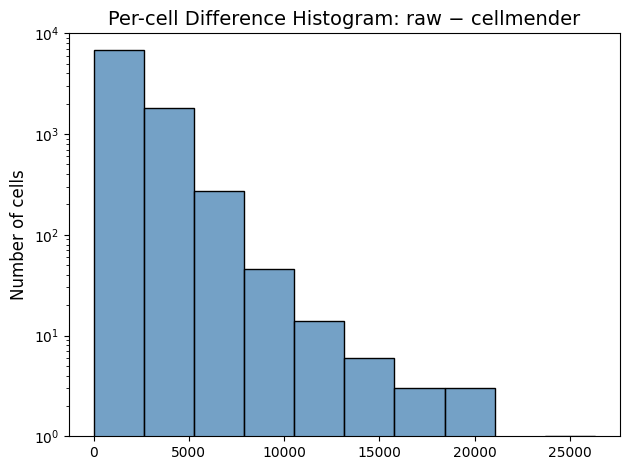

Total differences for CellBender: 1,518,602.0


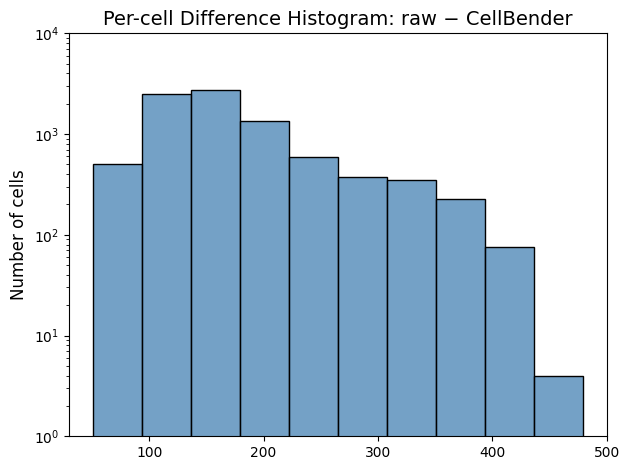

Total differences for SoupX: 2,643,782.444551751


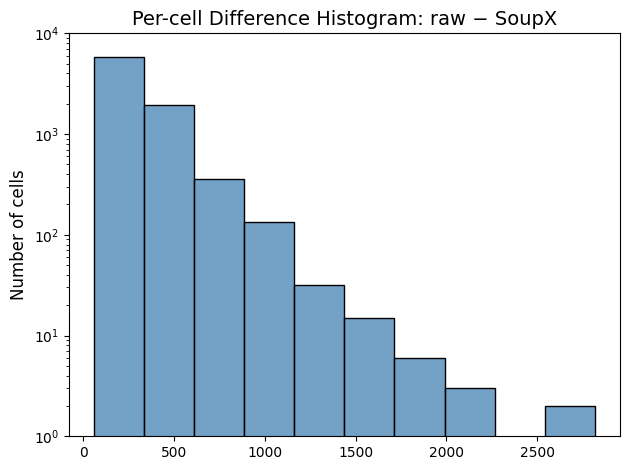

Total differences for DecontX: 6,456,046.266939605


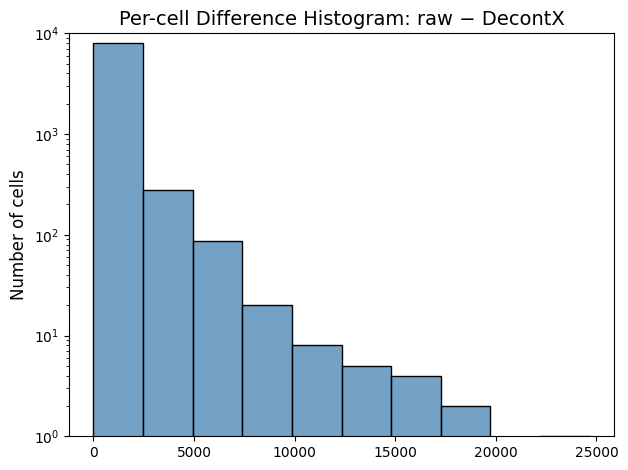

Total differences for scAR: 18,157,591.0


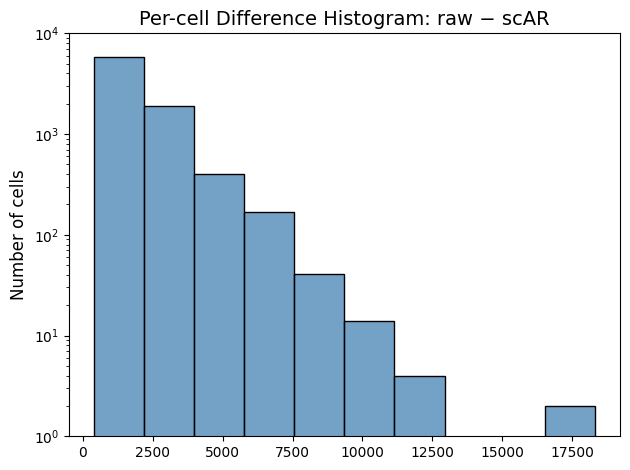

In [ ]:
cm_utils.plot_per_cell_difference(adata_raw, adata_cellmender, tool="cellmender", out_path=os.path.join(out_dir, "cellmender_per_cell_absolute_difference_from_raw.png"))
cm_utils.plot_per_cell_difference(adata_raw, adata_cellbender, tool="CellBender", out_path=os.path.join(out_dir, "cellbender_per_cell_absolute_difference_from_raw.png"))
if adata_soupx:
    cm_utils.plot_per_cell_difference(adata_raw, adata_soupx, tool="SoupX", out_path=os.path.join(out_dir, "soupx_per_cell_absolute_difference_from_raw.png"))
if adata_decontx:
    cm_utils.plot_per_cell_difference(adata_raw, adata_decontx, tool="DecontX", out_path=os.path.join(out_dir, "decontx_per_cell_absolute_difference_from_raw.png"))
if adata_scar:
    cm_utils.plot_per_cell_difference(adata_raw, adata_scar, tool="scAR", out_path=os.path.join(out_dir, "scar_per_cell_absolute_difference_from_raw.png"))

## stop here for tiny dataset

In [ ]:
# if dataset_name == "tiny_cellbender":
#     sys.exit()

## Alluvial plot of cluster differences

In [ ]:
adata_cellmender = cm_utils.run_scanpy_preprocessing_and_clustering(adata_cellmender, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
adata_cellmender = cm_utils.determine_cell_types(adata_cellmender, method="celltypist", model_pkl=model_pkl, filter_empty=False, verbose=verbose)

adata_cellbender = cm_utils.run_scanpy_preprocessing_and_clustering(adata_cellbender, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
adata_cellbender = cm_utils.determine_cell_types(adata_cellbender, method="celltypist", model_pkl=model_pkl, filter_empty=False, verbose=verbose)

if adata_soupx:
    adata_soupx = cm_utils.run_scanpy_preprocessing_and_clustering(adata_soupx, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
    adata_soupx = cm_utils.determine_cell_types(adata_soupx, method="celltypist", model_pkl=model_pkl, filter_empty=False, verbose=verbose)

if adata_decontx:
    adata_decontx = cm_utils.run_scanpy_preprocessing_and_clustering(adata_decontx, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
    adata_decontx = cm_utils.determine_cell_types(adata_decontx, method="celltypist", model_pkl=model_pkl, filter_empty=False, verbose=verbose)

if adata_scar:
    adata_scar = cm_utils.run_scanpy_preprocessing_and_clustering(adata_scar, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
    adata_scar = cm_utils.determine_cell_types(adata_scar, method="celltypist", model_pkl=model_pkl, filter_empty=False, verbose=verbose)

15:06:50 - INFO - Adata initial shape: (9000, 33694)
15:06:50 - INFO - 'counts' layer not found in adata. Creating 'counts' layer from adata.X and normalizing total counts to 1e4. This is done by copying the raw count matrix into a new layer called 'counts' and then applying total-count normalization to ensure that each cell has the same total count (e.g., 10,000). This step is important for downstream analyses that assume normalized data.
15:06:50 - INFO - 'log1p' not found in adata.uns. Applying log1p transformation to adata.X and storing in 'log1p' layer. This transformation is commonly used to stabilize variance and make the data more normally distributed, which can improve the performance of downstream analyses such as PCA and clustering.
15:06:50 - INFO - Identifying highly variable genes using 'highly_variable_genes' function. This step identifies the top 2000 genes that show the most variability across cells, which are often the most informative for downstream analyses like clu

15:08:20 - INFO - Running wompwomp for leiden
15:08:20 - DEBUG - conda run -p /home/jrich/miniconda3/envs/wompwomp_env /home/jrich/Desktop/wompwomp/exec/wompwomp plot_alluvial --df /home/jrich/Desktop/cellmender/notebooks/output/pbmc8k/alluvial_cluster_df.csv --graphing_columns cellbender cellmender soupx decontx scAR --coloring_algorithm left --disable_optimize_column_order -o /home/jrich/Desktop/cellmender/notebooks/output/pbmc8k/alluvial_cluster.png


[1] "Plot saved to: /home/jrich/Desktop/cellmender/notebooks/output/pbmc8k/alluvial_cluster.png"



Warning messages:
1: In to_lodes_form(data = data, axes = axis_ind, discern = params$discern) :
  Some strata appear at multiple axes.
2: In to_lodes_form(data = data, axes = axis_ind, discern = params$discern) :
  Some strata appear at multiple axes.
3: In to_lodes_form(data = data, axes = axis_ind, discern = params$discern) :
  Some strata appear at multiple axes.



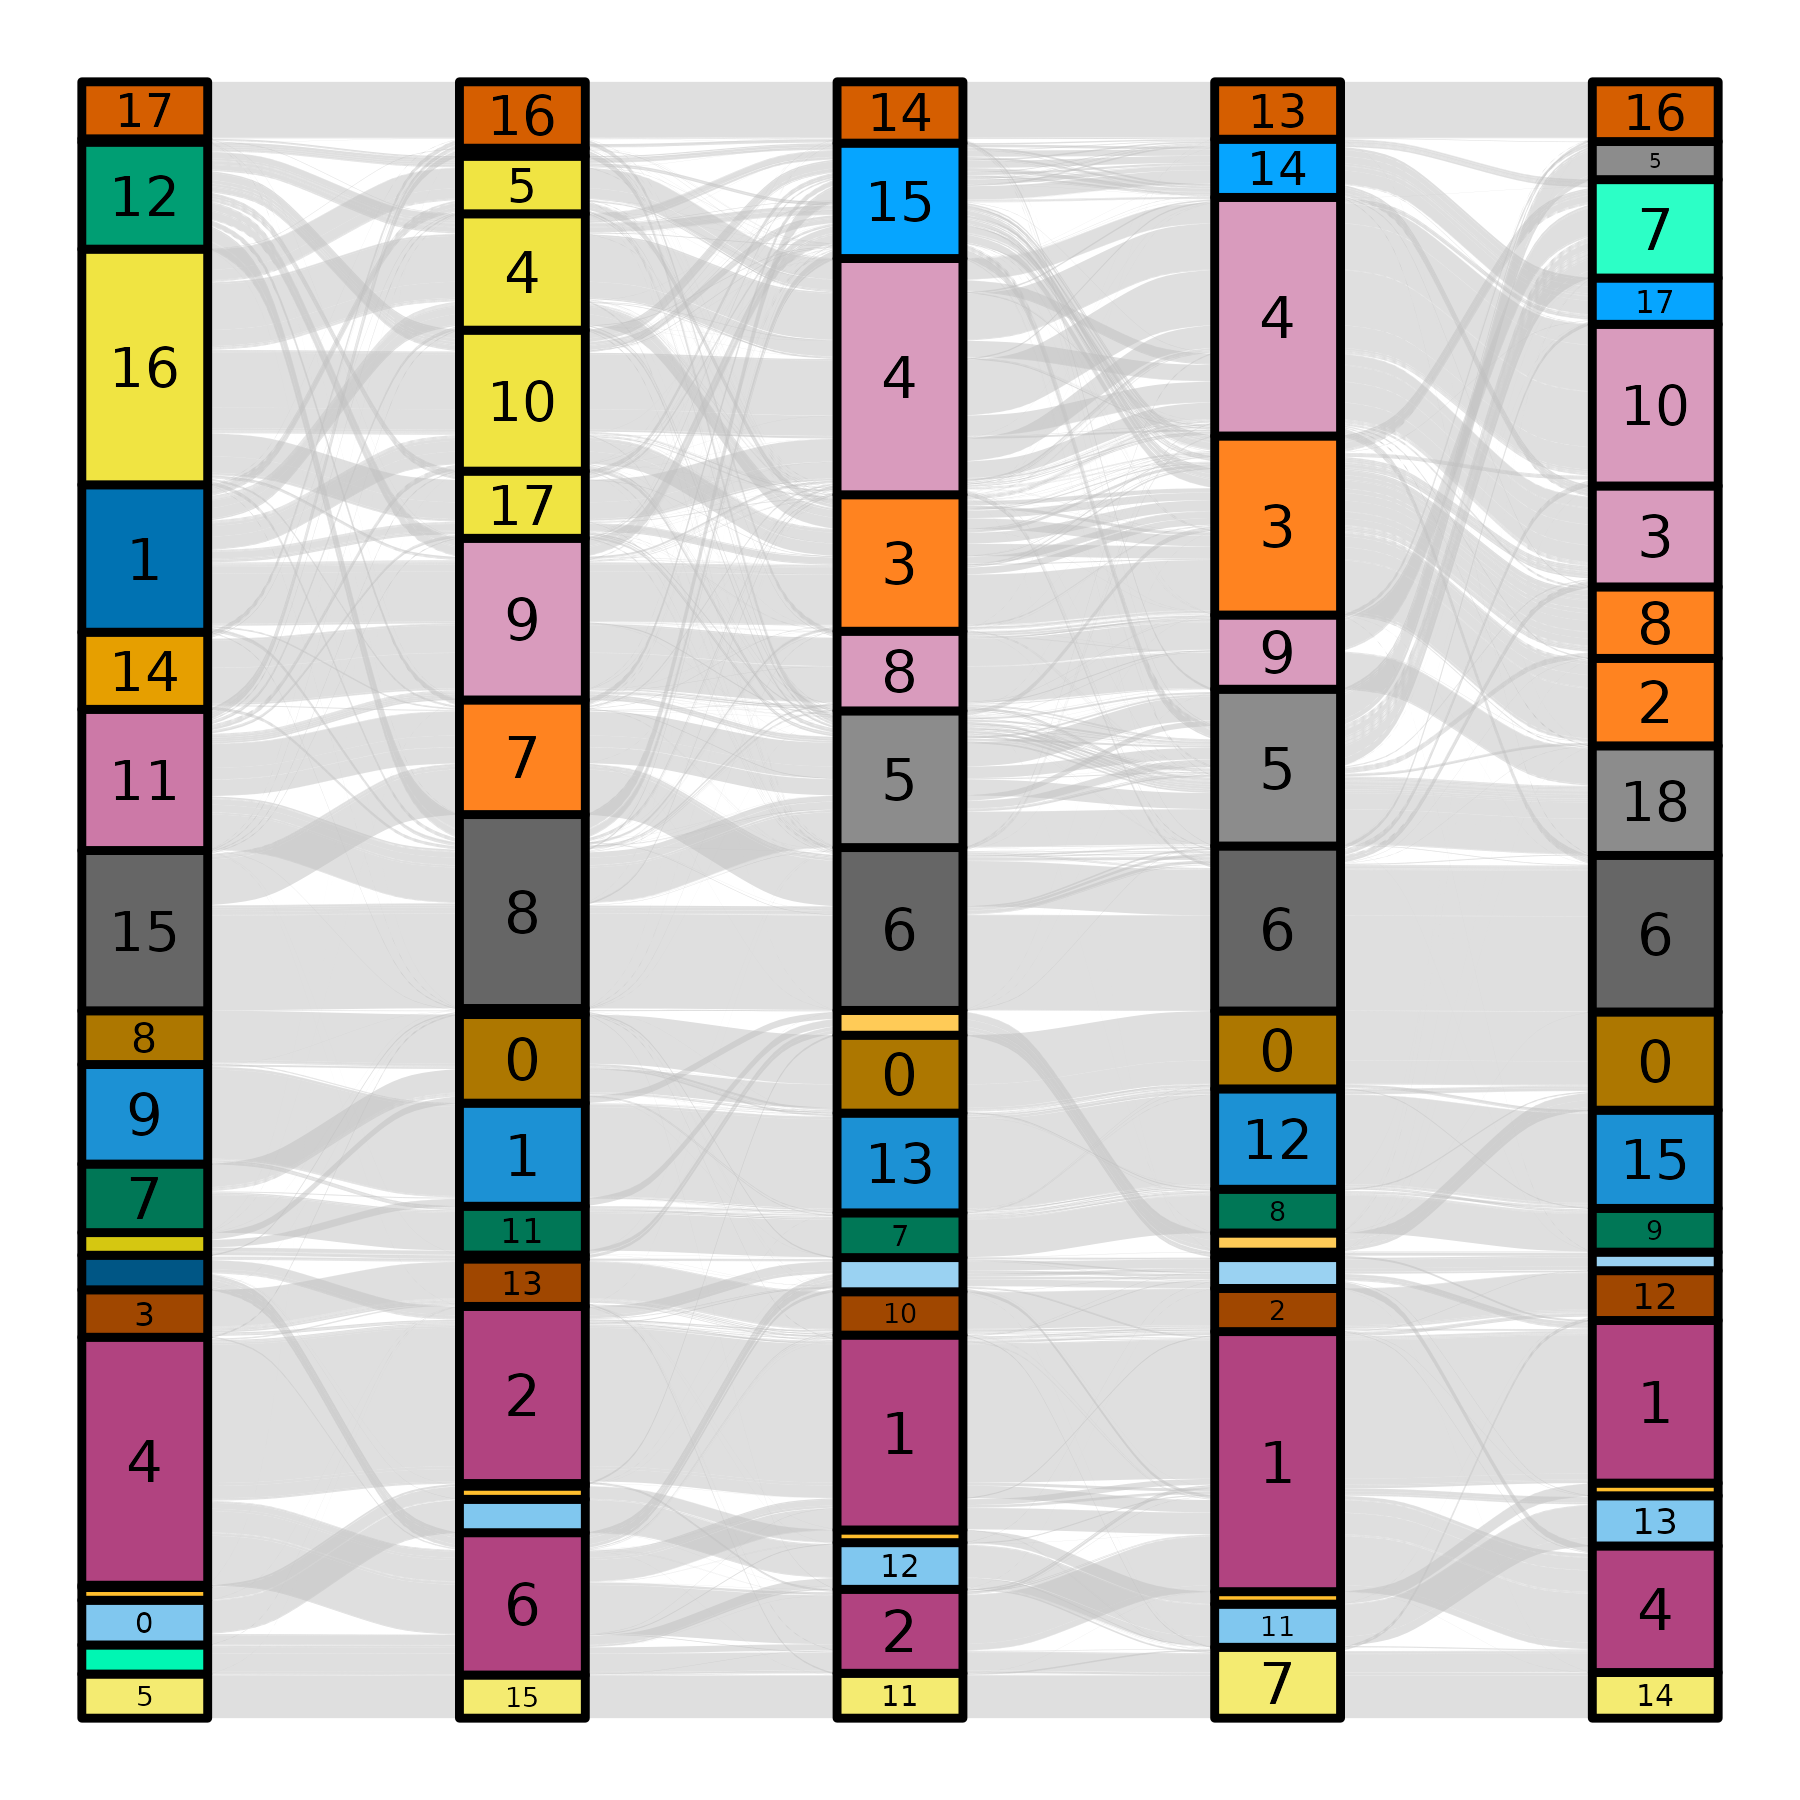

15:09:41 - INFO - Running wompwomp for celltype
15:09:41 - DEBUG - conda run -p /home/jrich/miniconda3/envs/wompwomp_env /home/jrich/Desktop/wompwomp/exec/wompwomp plot_alluvial --df /home/jrich/Desktop/cellmender/notebooks/output/pbmc8k/alluvial_celltype_df.csv --graphing_columns cellbender cellmender soupx decontx scAR --coloring_algorithm left --disable_optimize_column_order -o /home/jrich/Desktop/cellmender/notebooks/output/pbmc8k/alluvial_celltype.png


[1] "Plot saved to: /home/jrich/Desktop/cellmender/notebooks/output/pbmc8k/alluvial_celltype.png"



Warning messages:
1: In to_lodes_form(data = data, axes = axis_ind, discern = params$discern) :
  Some strata appear at multiple axes.
2: In to_lodes_form(data = data, axes = axis_ind, discern = params$discern) :
  Some strata appear at multiple axes.
3: In to_lodes_form(data = data, axes = axis_ind, discern = params$discern) :
  Some strata appear at multiple axes.



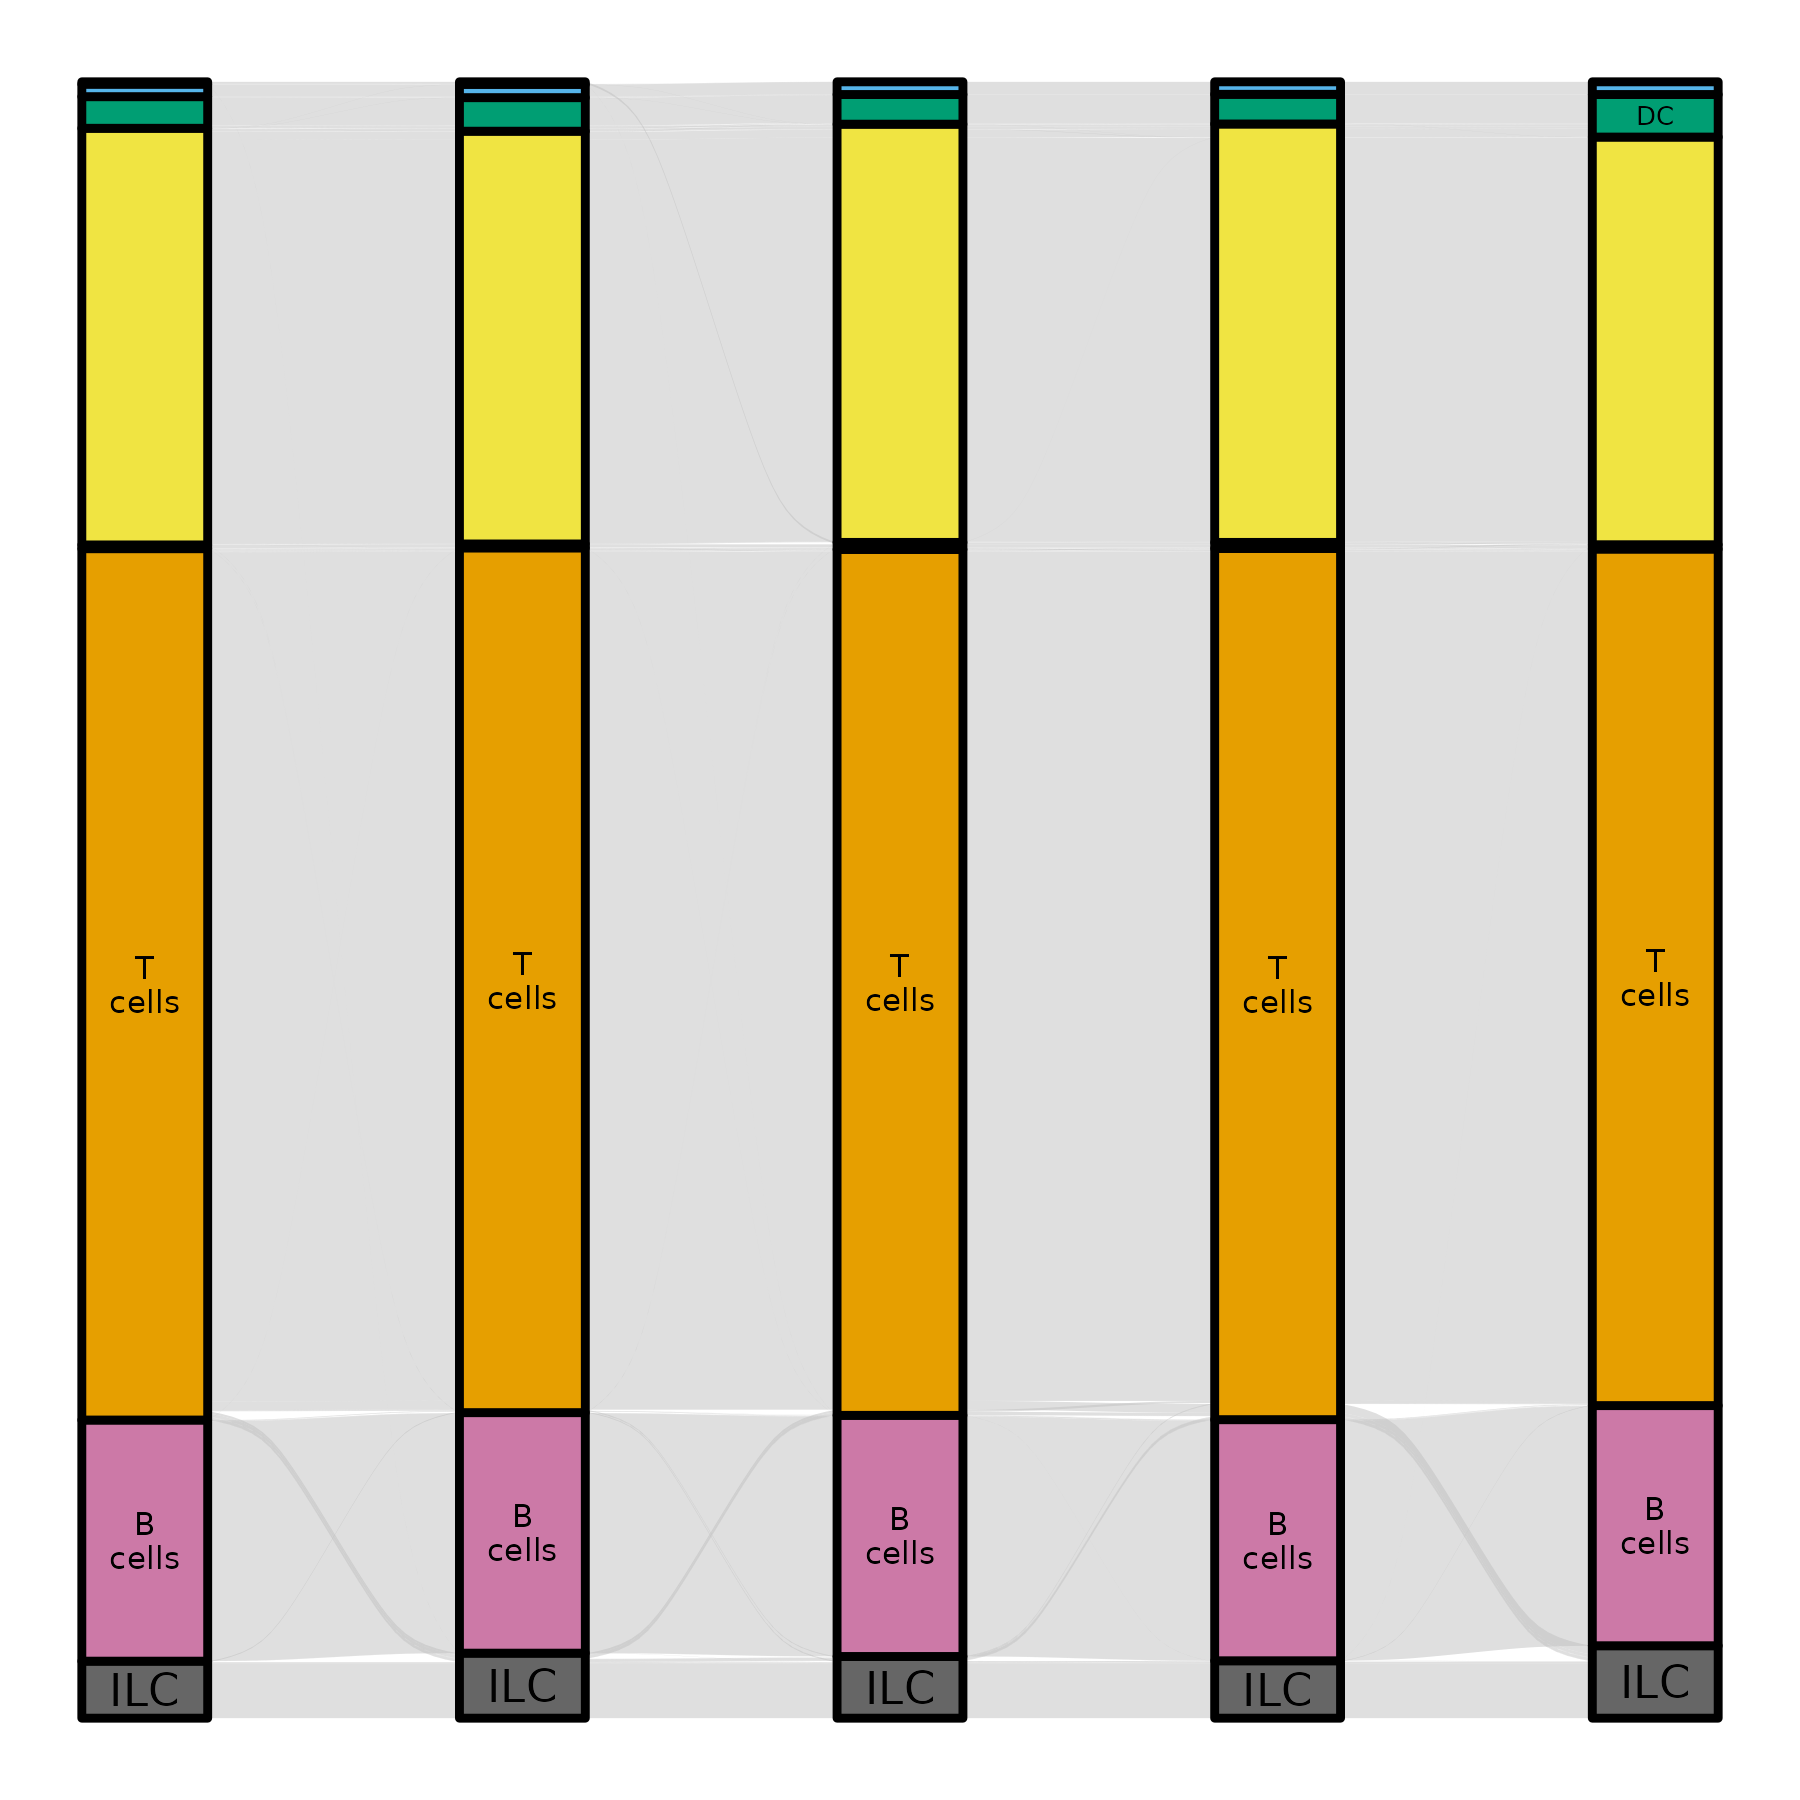

In [ ]:
col_names = ["cellbender", "cellmender", "soupx", "decontx", "scAR"]

# wrap in try-except block to catch errors due to wompwomp installation issues
try:
    wompwomp_leiden_df = cm_utils.plot_alluvial(adata_cellbender, adata_cellmender, adata_soupx, adata_decontx, adata_scar, names=col_names, displayed_column="leiden", merged_df_csv=os.path.join(out_dir, "alluvial_cluster_df.csv"), out_path=os.path.join(out_dir, "alluvial_cluster.png"), wompwomp_path=wompwomp_path, wompwomp_env=wompwomp_env, verbose=verbose)
    display(Image(filename=os.path.join(out_dir, "alluvial_cluster.png")))

    wompwomp_celltype_df = cm_utils.plot_alluvial(adata_cellbender, adata_cellmender, adata_soupx, adata_decontx, adata_scar, names=col_names, displayed_column="celltype", merged_df_csv=os.path.join(out_dir, "alluvial_celltype_df.csv"), out_path=os.path.join(out_dir, "alluvial_celltype.png"), wompwomp_path=wompwomp_path, wompwomp_env=wompwomp_env, verbose=verbose)
    display(Image(filename=os.path.join(out_dir, "alluvial_celltype.png")))
except Exception as e:
    print(f"Error generating alluvial plots with wompwomp: {e}")

## Dot plots

In [ ]:
# print(adata.obs["celltype"].value_counts())

# from celltypist import models
# model = models.Model.load(model_pkl)
# print(model.cell_types)

In [ ]:
if dataset_name == "pbmc8k":
    # Map fine-grained cell types to broad categories for matching to CellBender Fig 2
    reverse_map = {fine: broad for broad, fine_list in CellBender_Fig2_to_Immune_All_High_celltype_mapping.items() for fine in fine_list}
    adata_cellmender.obs["broad_celltype"] = adata_cellmender.obs["celltype"].map(reverse_map).fillna("Other")
    adata_cellbender.obs["broad_celltype"] = adata_cellbender.obs["celltype"].map(reverse_map).fillna("Other")
    if adata_soupx:
        adata_soupx.obs["broad_celltype"] = adata_soupx.obs["celltype"].map(reverse_map).fillna("Other")
    if adata_decontx:
        adata_decontx.obs["broad_celltype"] = adata_decontx.obs["celltype"].map(reverse_map).fillna("Other")
    if adata_scar:
        adata_scar.obs["broad_celltype"] = adata_scar.obs["celltype"].map(reverse_map).fillna("Other")
    celltype_column_dotplot = "broad_celltype"
else:
    celltype_column_dotplot = "celltype"

## 0 out counts below 0.5

In [ ]:
adata_cellmender = cm_utils.zero_out_low_counts(adata_cellmender, threshold=0.5)
adata_cellbender = cm_utils.zero_out_low_counts(adata_cellbender, threshold=0.5)
if adata_soupx:
    adata_soupx = cm_utils.zero_out_low_counts(adata_soupx, threshold=0.5)
if adata_decontx:
    adata_decontx = cm_utils.zero_out_low_counts(adata_decontx, threshold=0.5)
if adata_scar:
    adata_scar = cm_utils.zero_out_low_counts(adata_scar, threshold=0.5)

In [ ]:
adata_cellmender.obs.head()

,is_empty,celltype,cell_ambient_fraction,alpha_hat,z_hat,leiden,broad_celltype
AAACCTGAGCATCATC-1,False,B cells,0.01,0.347295,0,0,B
AAACCTGAGCTAACTC-1,False,Monocytes,0.01,0.378090,5,2,Monocytes/neutrophils
AAACCTGAGCTAGTGG-1,False,T cells,0.01,0.542186,6,4,T
AAACCTGCACATTAGC-1,False,T cells,0.01,0.354822,6,5,T
AAACCTGCACTGTTAG-1,False,Monocytes,0.01,0.399114,5,6,Monocytes/neutrophils


CellMender Raw Data Dotplot


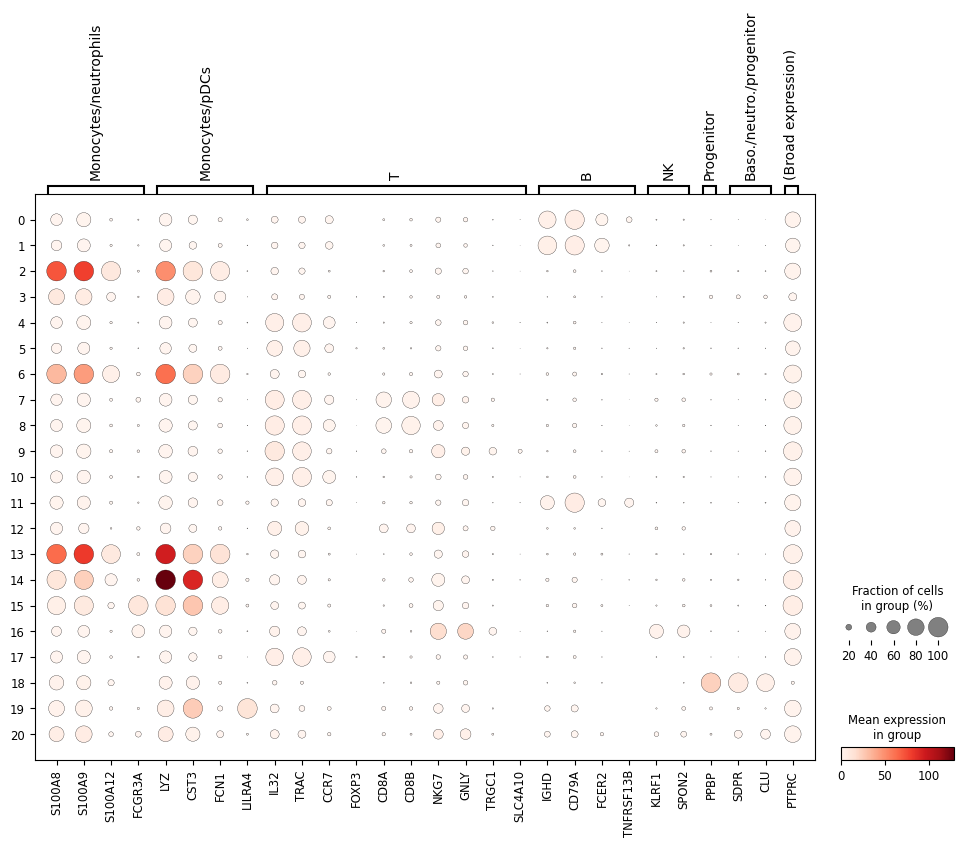

------------------------------
CellMender Processed Data Dotplot


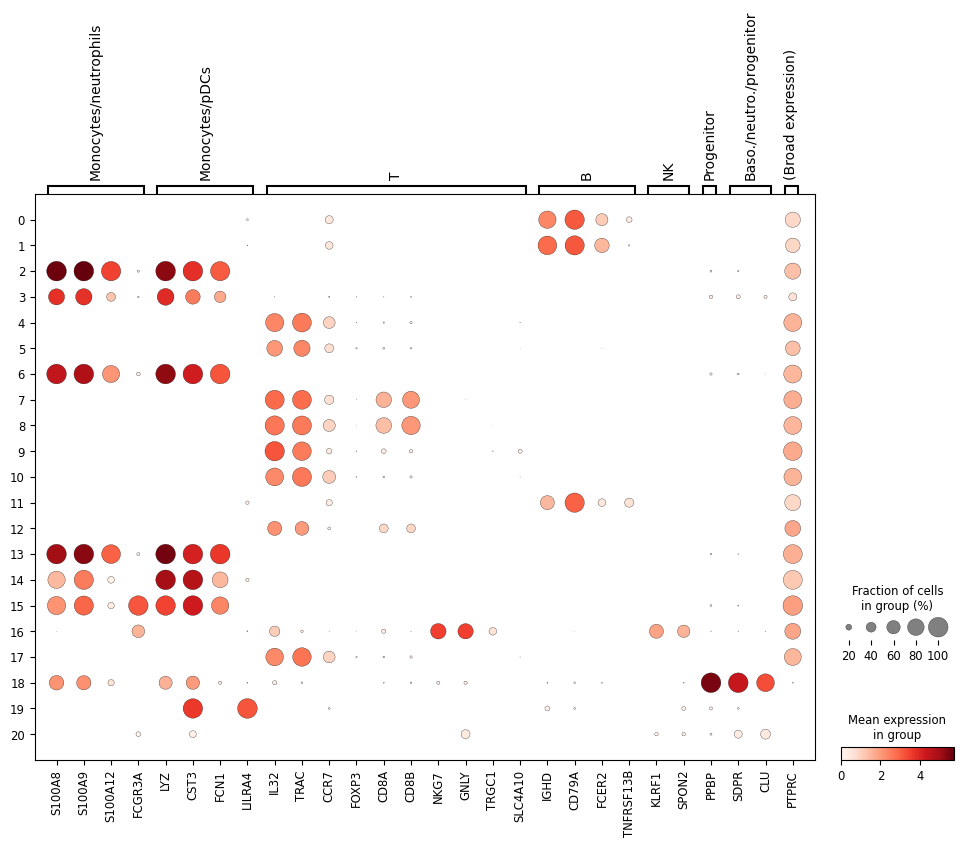

------------------------------
CellBender Raw Data Dotplot


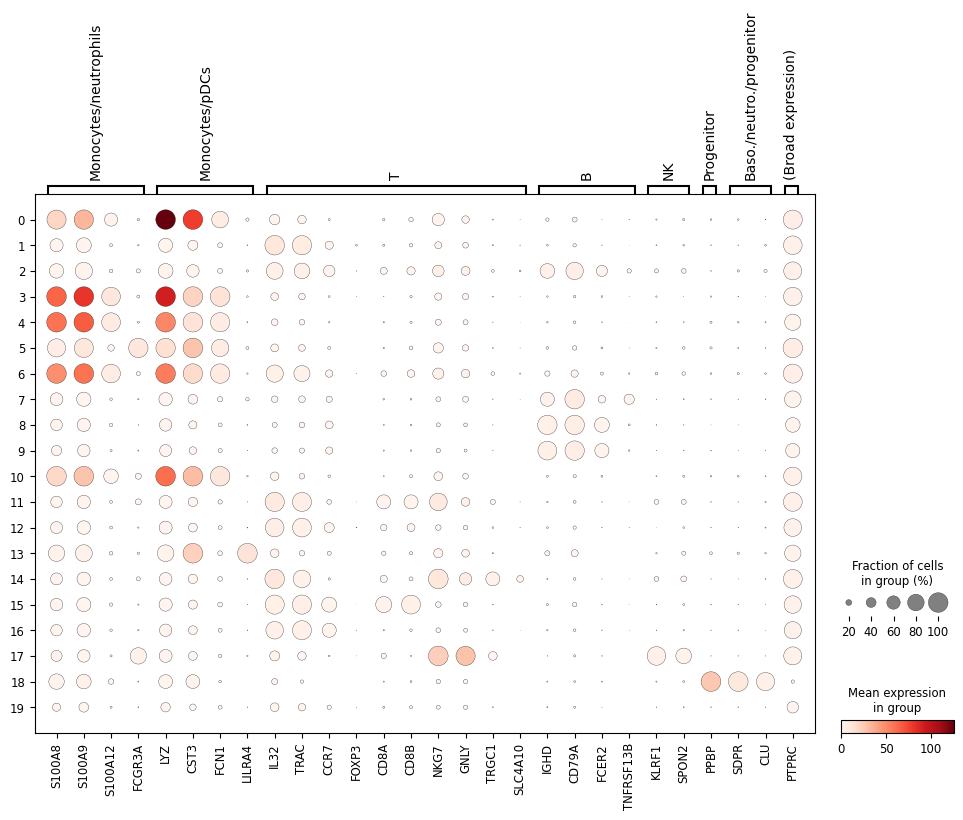

------------------------------
CellBender Processed Data Dotplot


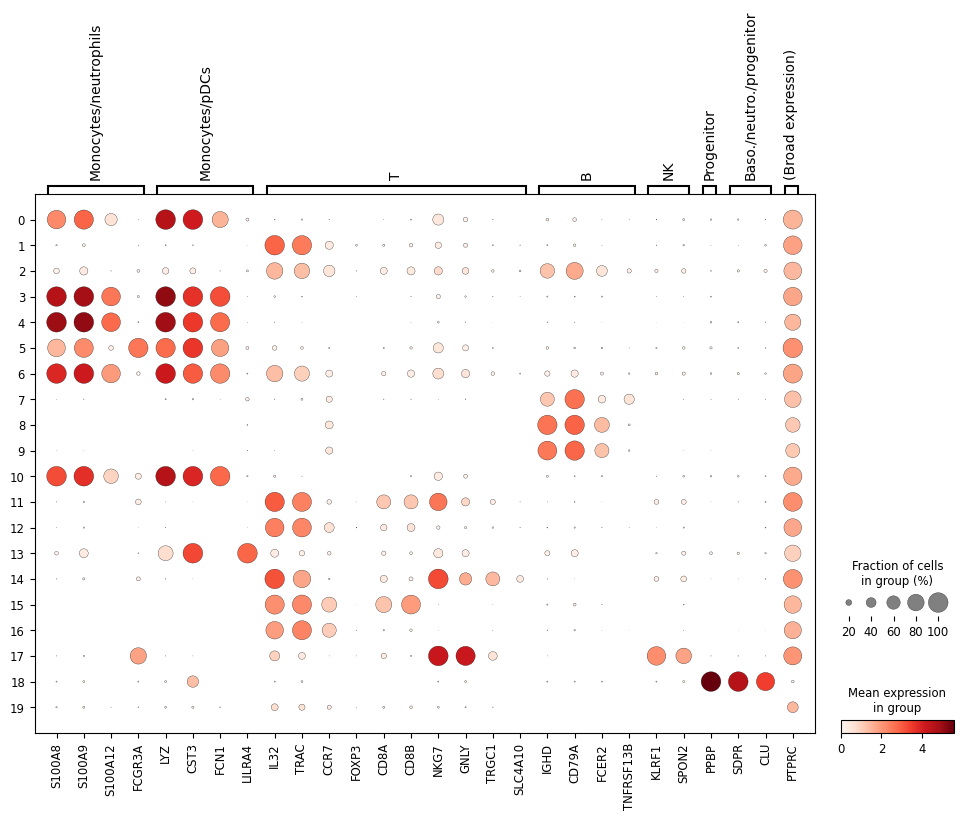

------------------------------
SoupX Raw Data Dotplot


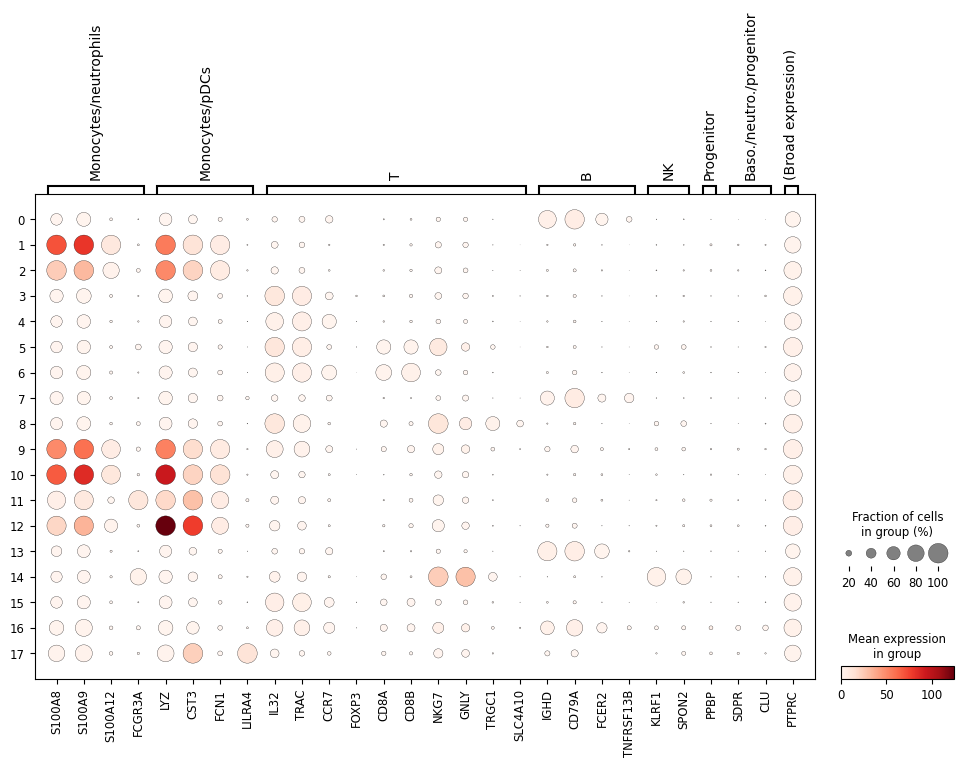

------------------------------
SoupX Processed Data Dotplot


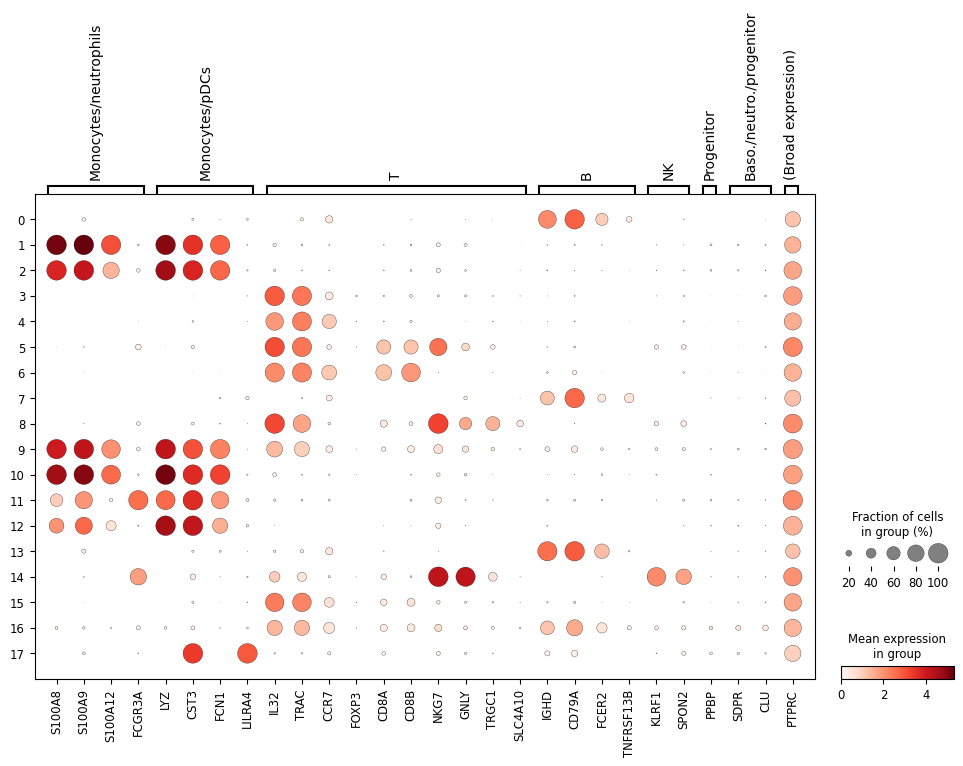

------------------------------
DecontX Raw Data Dotplot


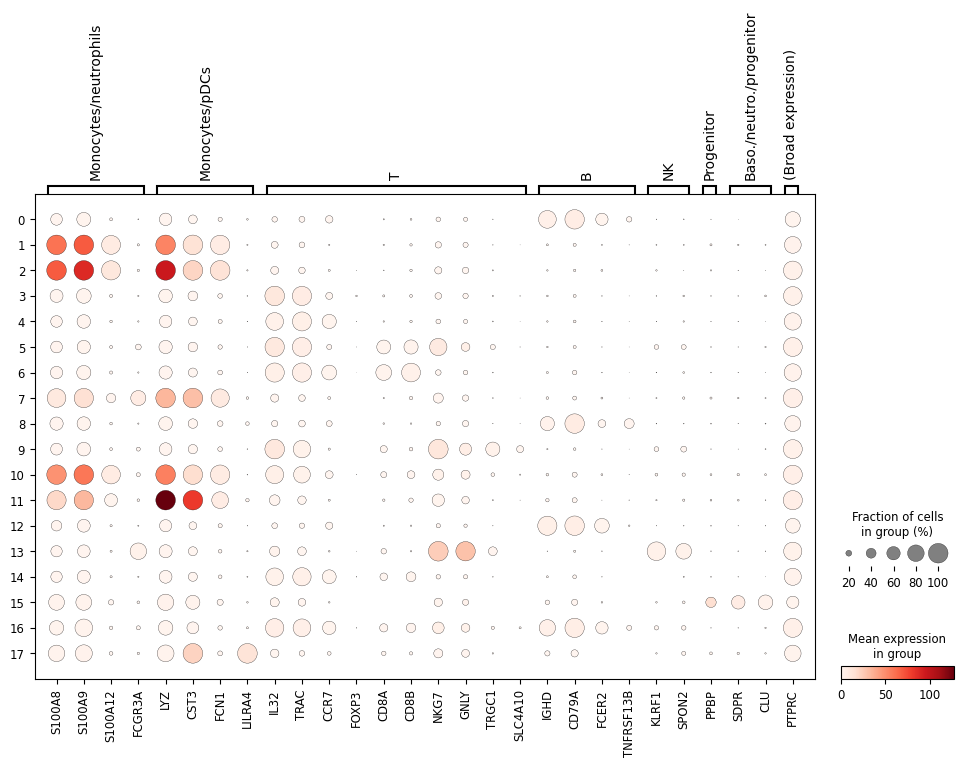

------------------------------
DecontX Processed Data Dotplot


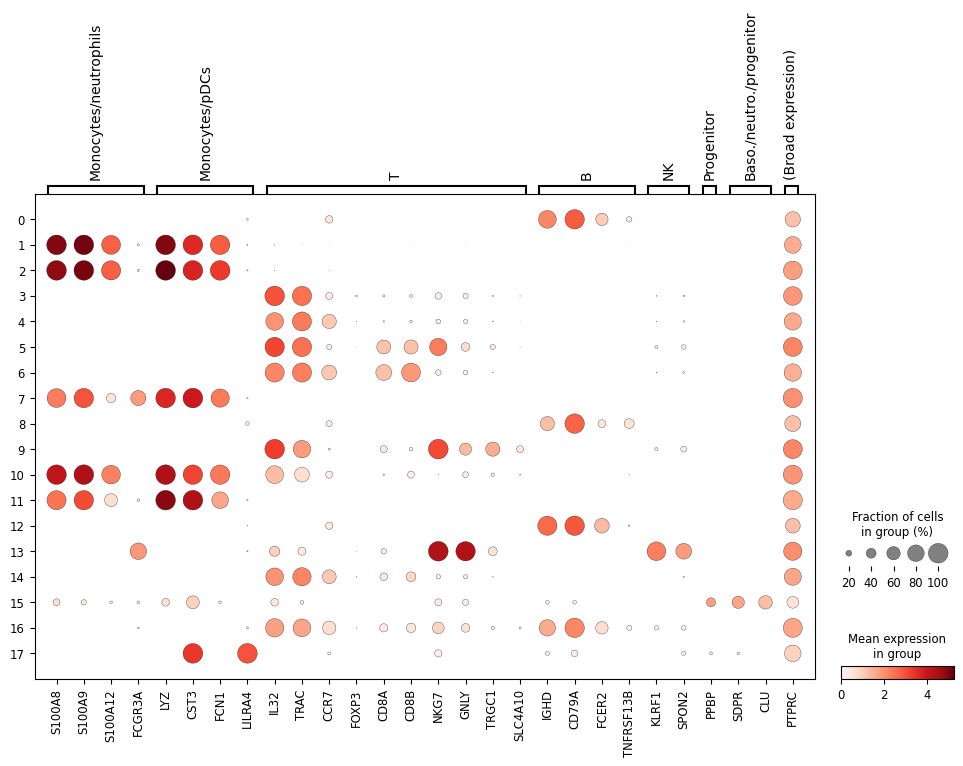

------------------------------
scAR Raw Data Dotplot


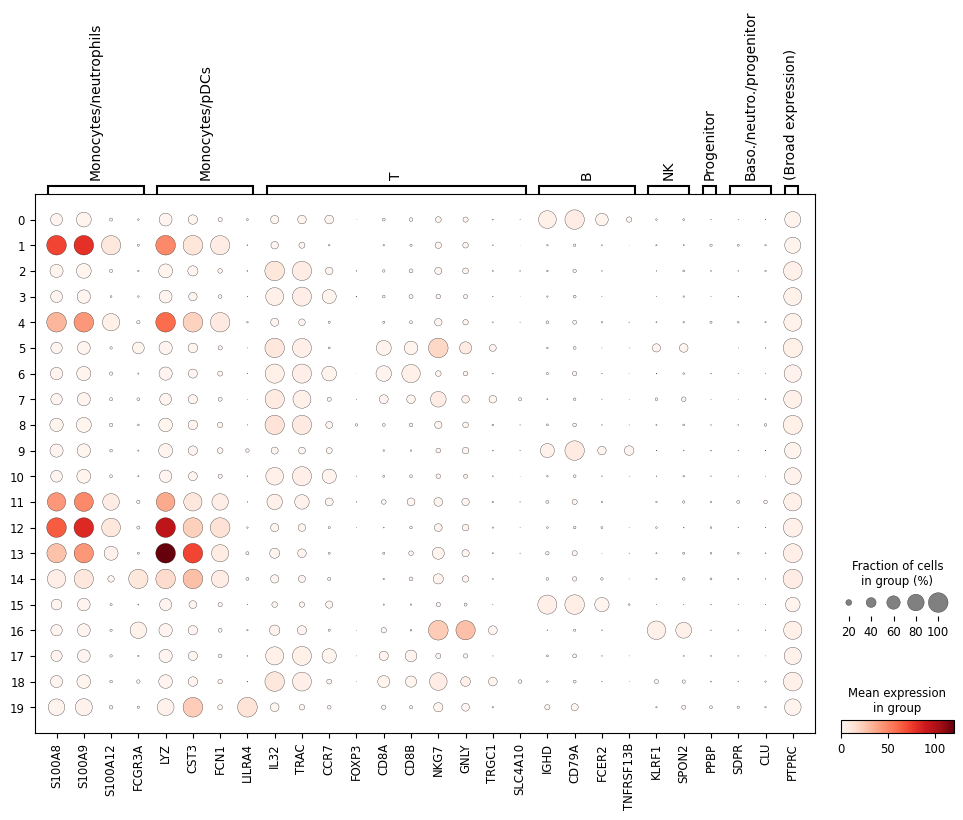

------------------------------
scAR Processed Data Dotplot


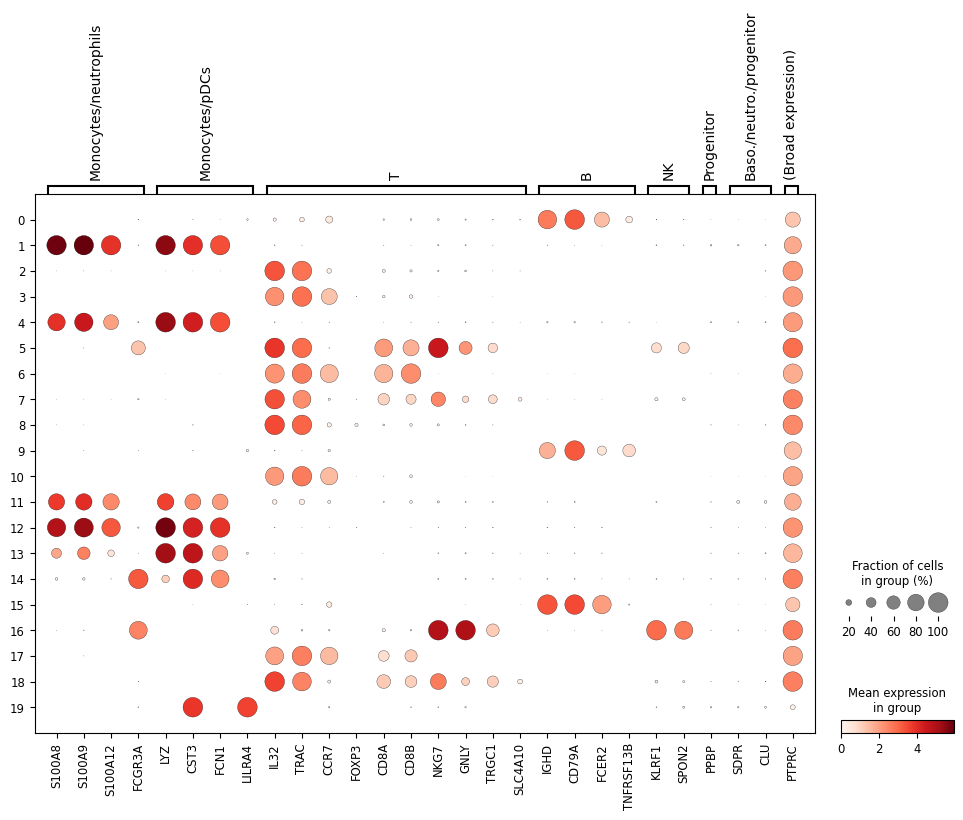

------------------------------


In [ ]:
cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_cellmender, marker_genes, celltype_column=celltype_column_dotplot, title_raw="CellMender Raw Data Dotplot", title_processed="CellMender Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_cellmender_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_cellmender.png"))
cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_cellbender, marker_genes, celltype_column=celltype_column_dotplot, title_raw="CellBender Raw Data Dotplot", title_processed="CellBender Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_cellbender_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_cellbender.png"))
if adata_soupx:
    cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_soupx, marker_genes, celltype_column=celltype_column_dotplot, title_raw="SoupX Raw Data Dotplot", title_processed="SoupX Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_soupx_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_soupx.png"))
if adata_decontx:
    cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_decontx, marker_genes, celltype_column=celltype_column_dotplot, title_raw="DecontX Raw Data Dotplot", title_processed="DecontX Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_decontx_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_decontx.png"))
if adata_scar:
    cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_scar, marker_genes, celltype_column=celltype_column_dotplot, title_raw="scAR Raw Data Dotplot", title_processed="scAR Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_scar_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_scar.png"))

## Standardize clusters to CellBender

In [ ]:
adata_cellmender.obs["leiden_cellbender"] = adata_cellbender.obs["leiden"].reindex(adata_cellmender.obs.index)
cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_cellmender, marker_genes, celltype_column=celltype_column_dotplot, cluster_column="leiden_cellbender", title_raw="CellMender Raw Data Dotplot", title_processed="CellMender Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_cellmender_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_cellmender.png"))

if adata_soupx:
    adata_soupx.obs["leiden_cellbender"] = adata_cellbender.obs["leiden"].reindex(adata_soupx.obs.index)
    cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_soupx, marker_genes, celltype_column=celltype_column_dotplot, cluster_column="leiden_cellbender", title_raw="SoupX Raw Data Dotplot", title_processed="SoupX Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_soupx_raw_with_cellbender_clusters.png"), out_path_processed=os.path.join(out_dir, "dotplot_soupx_with_cellbender_clusters.png"))
if adata_decontx:
    adata_decontx.obs["leiden_cellbender"] = adata_cellbender.obs["leiden"].reindex(adata_decontx.obs.index)
    cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_decontx, marker_genes, celltype_column=celltype_column_dotplot, cluster_column="leiden_cellbender", title_raw="DecontX Raw Data Dotplot", title_processed="DecontX Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_decontx_raw_with_cellbender_clusters.png"), out_path_processed=os.path.join(out_dir, "dotplot_decontx_with_cellbender_clusters.png"))
if adata_scar:
    adata_scar.obs["leiden_cellbender"] = adata_cellbender.obs["leiden"].reindex(adata_scar.obs.index)
    cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_scar, marker_genes, celltype_column=celltype_column_dotplot, cluster_column="leiden_cellbender", title_raw="scAR Raw Data Dotplot", title_processed="scAR Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_scar_raw_with_cellbender_clusters.png"), out_path_processed=os.path.join(out_dir, "dotplot_scar_with_cellbender_clusters.png"))

## Bonus: runtime (on our machine)

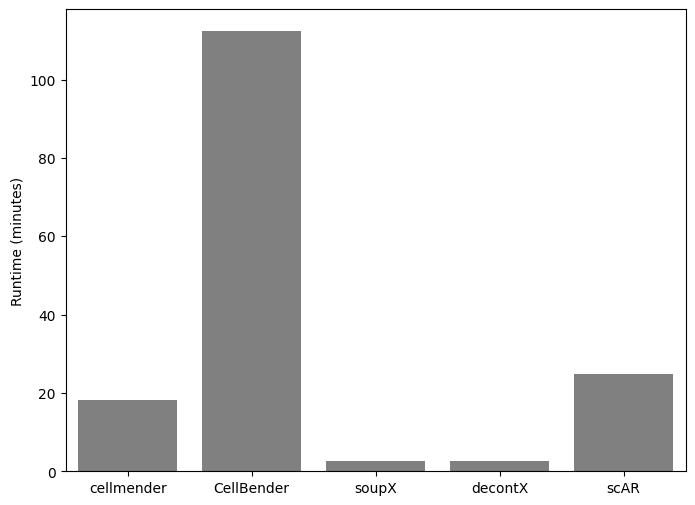

In [ ]:
runtimes = {
    "cellmender": (18 + 8/60),  # 18 minutes, 8 seconds
    "CellBender (CPU)": (1*60 + 52 + 20/60),  # 1 hour, 52 minutes, 20 seconds
    "CellBender (GPU)": (20 + 17/60),  # 20 minutes, 17 seconds - NVIDIA RTX 3070
    "soupX": (2 + 43/60),  # 2 minutes, 43 seconds
    "decontX": (2 + 37/60),  # 2 minutes, 37 seconds
    "scAR": (24 + 52/60)  # 24 minutes, 52 seconds
}

plt.figure(figsize=(8,6))
sns.barplot(x=list(runtimes.keys()), y=list(runtimes.values()), color="gray")
plt.ylabel("Runtime (minutes)")
plt.savefig(os.path.join(out_dir, "runtime_comparison.png"))
plt.show()

## Bonus: Number of parameters in cellmender and CellBender

In [ ]:
cellmender_parameters = cm_utils.count_cellmender_parameters(cellmender_log_file)
print(cellmender_parameters)

12:41:52 - INFO - Number of parameters in the cellmender model: 393,247 (alpha_i: 9,000, beta: 1, gamma_type: 81,000, p_k: 303,246)


# OLD EXAMPLE OUTPUT

In [ ]:
import importlib
import cellmender.utils as cm_utils
importlib.reload(cm_utils)
from cellmender.utils import count_cellbender_parameters

cellbender_parameters = cm_utils.count_cellbender_parameters(cellbender_ckpt)
print(f"Total number of parameters in the CellBender model checkpoint: {cellbender_parameters}")


=== Model Architecture (inferred from state_dict) ===
Total parameters: 31,758,725

encoder_z$$$network.0.layer.0.weight               | Shape: torch.Size([512, 15166]) | Params: 7,764,992
encoder_z$$$network.0.layer.0.bias                 | Shape: torch.Size([512])    | Params: 512
encoder_z$$$loc_out.weight                         | Shape: torch.Size([64, 512]) | Params: 32,768
encoder_z$$$loc_out.bias                           | Shape: torch.Size([64])     | Params: 64
encoder_z$$$sig_out.weight                         | Shape: torch.Size([64, 512]) | Params: 32,768
encoder_z$$$sig_out.bias                           | Shape: torch.Size([64])     | Params: 64
encoder_other$$$layer1.weight                      | Shape: torch.Size([512, 15170]) | Params: 7,767,040
encoder_other$$$layer1.bias                        | Shape: torch.Size([512])    | Params: 512
encoder_other$$$batchnorm1.weight                  | Shape: torch.Size([512])    | Params: 512
encoder_other$$$batchnorm1.bias   